# Smart Sales Analytics Platform

# Import des packages, données & fichiers utilitaires

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlalchemy
import os, sys

sys.path.append(os.path.join(os.path.dirname(""), ".."))
from config import DB_PATH

# Style global
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

In [2]:
# Chargement depuis la base SQLite
engine = sqlalchemy.create_engine(f"sqlite:///{DB_PATH}")
df = pd.read_sql("SELECT * FROM sales", con=engine)
df["order_date"] = pd.to_datetime(df["order_date"])
df["ship_date"]  = pd.to_datetime(df["ship_date"])

print(f"Dataset chargé : {df.shape[0]} lignes · {df.shape[1]} colonnes")
df.head()

Dataset chargé : 9994 lignes · 36 colonnes


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,quarter,is_q4,is_low_month,weekday_num,is_weekend,discount_tier,high_discount,is_profitable,revenue_per_unit,margin_class
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,4,1,0,1,0,none,0,1,130.98,low
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,4,1,0,1,0,none,0,1,243.98,good
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,2,0,0,6,1,none,0,1,7.31,good
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,4,1,0,6,1,high,1,0,191.52,negative
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,4,1,0,6,1,medium,0,1,11.18,low


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 36 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   row_id            9994 non-null   int64         
 1   order_id          9994 non-null   object        
 2   order_date        9994 non-null   datetime64[ns]
 3   ship_date         9994 non-null   datetime64[ns]
 4   ship_mode         9994 non-null   object        
 5   customer_id       9994 non-null   object        
 6   customer_name     9994 non-null   object        
 7   segment           9994 non-null   object        
 8   country           9994 non-null   object        
 9   city              9994 non-null   object        
 10  state             9994 non-null   object        
 11  postal_code       9994 non-null   int64         
 12  region            9994 non-null   object        
 13  product_id        9994 non-null   object        
 14  category          9994 n

## Structure du dataset

Le dataset contient **9 994 lignes et 26 colonnes**, sans aucune valeur nulle.
C'est un signal positif : le pipeline ETL a bien fait son travail de nettoyage.

Les colonnes se répartissent en 4 types distincts. Les **14 colonnes texte** (object)
portent les dimensions d'analyse : qui a commandé, quoi, où, comment.
Les **4 colonnes float** concentrent les métriques financières : ventes, profit,
remise et marge. Les **6 colonnes entières** incluent les dimensions temporelles
calculées (année, mois, délai de livraison) ainsi que les quantités.
Les **2 colonnes datetime** permettront l'analyse des séries temporelles.

Les 5 dernières colonnes (`delivery_days`, `year`, `month`, `month_label`,
`profit_margin`) sont des **features calculées** ajoutées lors du transform ETL,
elles seront centrales dans nos analyses.

In [4]:
df.describe()

,row_id,order_date,ship_date,postal_code,sales,quantity,discount,profit,delivery_days,year,month,profit_margin,quarter,is_q4,is_low_month,weekday_num,is_weekend,high_discount,is_profitable,revenue_per_unit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896,3.958175,2015.722233,7.809686,0.120314,2.882329,0.370022,0.030018,3.206324,0.336702,0.116670,0.806284,60.918928
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.000000,2014.000000,1.000000,-2.750000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.340000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750,3.000000,2015.000000,5.000000,0.075000,2.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,5.470000
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500,4.000000,2016.000000,9.000000,0.270000,3.000000,0.000000,0.000000,4.000000,0.000000,0.000000,1.000000,16.270000
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000,5.000000,2017.000000,11.000000,0.362500,4.000000,1.000000,0.000000,5.000000,1.000000,0.000000,1.000000,63.940000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000,7.000000,2017.000000,12.000000,0.500000,4.000000,1.000000,1.000000,6.000000,1.000000,1.000000,1.000000,3773.080000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108,1.747567,1.123555,3.284654,0.466754,1.058086,0.482834,0.170645,2.122925,0.472606,0.321043,0.395229,142.927476


## Statistiques descriptives — ce que les chiffres révèlent

**Métriques financières**
Les ventes moyennes sont de **230$** par commande, mais le max atteint **22 638$**
avec un écart-type de 623$ — la distribution est très asymétrique, quelques grosses
commandes tirent la moyenne vers le haut. Le profit moyen est de **28.6$** mais
descend jusqu'à **-6 599$** : certaines commandes sont massivement déficitaires,
probablement à cause des remises. La marge moyenne de **12%** reste correcte,
mais le min à **-2.75** (-275%) confirme des cas extrêmes à investiguer.

**Remises**
75% des commandes ont une remise de 0.20 (20%) ou moins, mais le max est à 0.80
(80%). C'est un signal fort : les fortes remises sont probablement la principale
cause des profits négatifs. On le vérifiera dans la suite.

**Délai de livraison**
Entre 0 et 7 jours, moyenne à **4 jours**. La distribution semble propre,
sans valeurs aberrantes majeures.

**Période couverte**
Les données vont de **janvier 2014 à janvier 2018**, soit 4 ans complets.
C'est suffisant pour détecter des tendances saisonnières et entraîner un modèle
de forecast crédible.

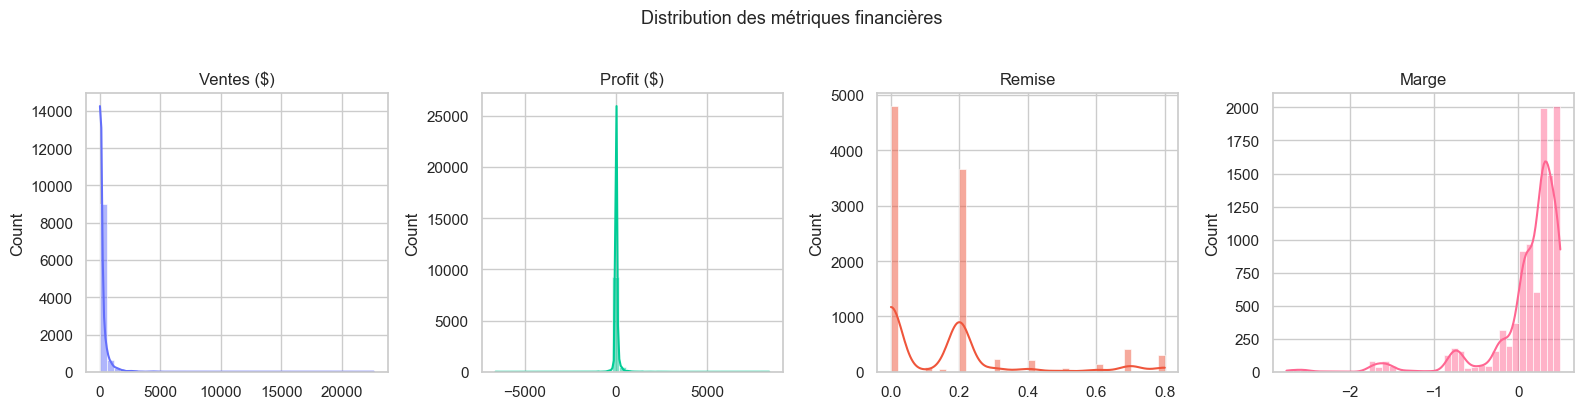

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

cols    = ["sales", "profit", "discount", "profit_margin"]
colors  = ["#636EFA", "#00CC96", "#EF553B", "#FF6692"]
titres  = ["Ventes ($)", "Profit ($)", "Remise", "Marge"]

for ax, col, color, titre in zip(axes, cols, colors, titres):
    sns.histplot(df[col], ax=ax, color=color, bins=40, kde=True)
    ax.set_title(titre)
    ax.set_xlabel("")

plt.suptitle("Distribution des métriques financières", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Distribution des métriques financières — lecture visuelle

**Ventes** — distribution fortement asymétrique à droite (long tail). L'écrasante
majorité des commandes sont sous 1 000$, mais quelques commandes exceptionnelles
montent jusqu'à 22 000$. Ce type de distribution est classique en e-commerce :
un modèle basé sur la moyenne serait peu représentatif, il faudra penser à une
transformation logarithmique si on l'utilise comme variable cible ML.

**Profit** — distribution très resserrée autour de zéro avec des queues épaisses
des deux côtés. Cela confirme la coexistence de commandes très rentables et de
commandes très déficitaires dans le même dataset. Le pic central indique que la
majorité des commandes génèrent un profit faible mais positif.

**Remise** — distribution discrète, pas continue. Les remises sont appliquées par
paliers fixes : 0%, 20%, 30%, 40%, 70%, 80%. Ce n'est pas un hasard, c'est une
politique commerciale. Cela change notre approche : la remise se traite comme une
variable **catégorielle ordinale**, pas comme une variable continue.

**Marge** — distribution bimodale avec un pic autour de 0 et un second pic vers
0.5. Le côté gauche (marges négatives) est préoccupant. On croisera cette variable
avec la remise dans la prochaine étape pour confirmer le lien entre forte remise
et marge négative.

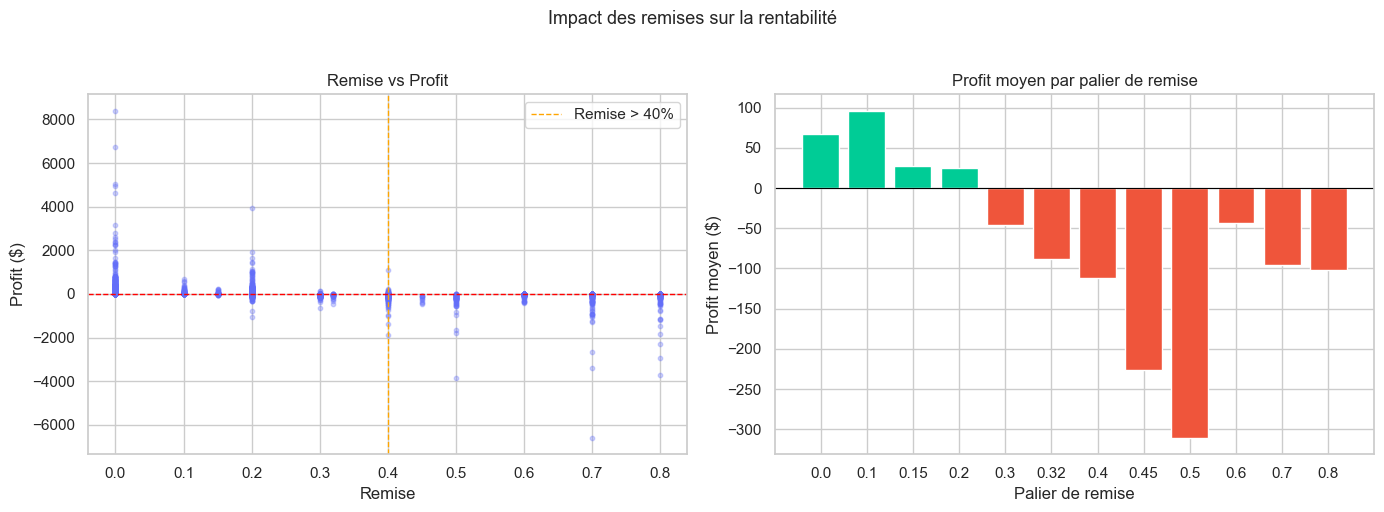

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter remise vs profit
axes[0].scatter(df["discount"], df["profit"], alpha=0.3, color="#636EFA", s=10)
axes[0].axhline(0, color="red", linewidth=1, linestyle="--")
axes[0].axvline(0.4, color="orange", linewidth=1, linestyle="--", label="Remise > 40%")
axes[0].set_xlabel("Remise")
axes[0].set_ylabel("Profit ($)")
axes[0].set_title("Remise vs Profit")
axes[0].legend()

# Profit moyen par palier de remise
discount_profit = (
    df.groupby("discount")["profit"]
    .mean()
    .reset_index()
    .sort_values("discount")
)
axes[1].bar(
    discount_profit["discount"].astype(str),
    discount_profit["profit"],
    color=["#00CC96" if p > 0 else "#EF553B" for p in discount_profit["profit"]]
)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Palier de remise")
axes[1].set_ylabel("Profit moyen ($)")
axes[1].set_title("Profit moyen par palier de remise")

plt.suptitle("Impact des remises sur la rentabilité", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Impact des remises sur la rentabilité — un signal business critique

Le graphique de gauche est sans appel : au-delà de 40% de remise, **toutes les
commandes ou presque basculent en territoire négatif**. La ligne rouge à zéro
matérialise clairement la frontière entre rentabilité et perte.

Le graphique de droite quantifie ce basculement palier par palier. Les remises
à 0%, 10%, 15% et 20% génèrent un profit moyen positif (entre +20$ et +95$).
À partir de 30%, le profit moyen devient négatif. Le palier à **50% est le pire**
avec une perte moyenne de -300$ par commande — c'est une destruction de valeur
systématique.

Ce n'est pas une anomalie ponctuelle, c'est une **politique commerciale qui coûte
de l'argent**. La question business qui découle naturellement est : ces remises
génèrent-elles suffisamment de volume pour compenser les pertes ? On le vérifiera
en croisant remise, quantité et catégorie de produit.

Cette relation remise → profit sera également une feature importante dans nos
modèles ML, notamment pour la détection d'anomalies et la segmentation clients.

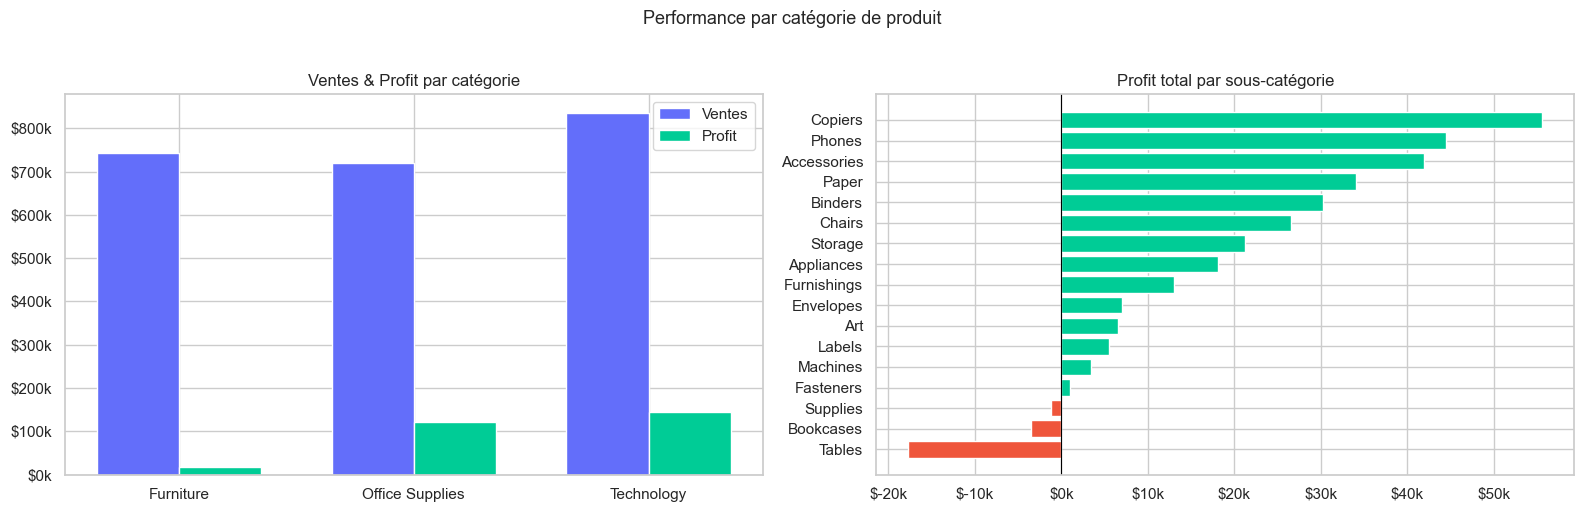

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Ventes et profit par catégorie
cat_df = df.groupby("category")[["sales", "profit"]].sum().reset_index()
x = np.arange(len(cat_df))
w = 0.35
axes[0].bar(x - w/2, cat_df["sales"],  width=w, label="Ventes",  color="#636EFA")
axes[0].bar(x + w/2, cat_df["profit"], width=w, label="Profit",  color="#00CC96")
axes[0].set_xticks(x)
axes[0].set_xticklabels(cat_df["category"])
axes[0].set_title("Ventes & Profit par catégorie")
axes[0].legend()
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda val, _: f"${val/1000:.0f}k")
)

# Profit par sous-catégorie (trié)
subcat_df = (
    df.groupby("sub_category")["profit"]
    .sum()
    .reset_index()
    .sort_values("profit")
)
colors = ["#EF553B" if p < 0 else "#00CC96" for p in subcat_df["profit"]]
axes[1].barh(subcat_df["sub_category"], subcat_df["profit"], color=colors)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Profit total par sous-catégorie")
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda val, _: f"${val/1000:.0f}k")
)

plt.suptitle("Performance par catégorie de produit", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Performance par catégorie de produit — le paradoxe du Furniture

Le graphique de gauche révèle un paradoxe frappant : **Furniture génère autant
de ventes que Office Supplies (~730k$) mais un profit quasi nul**. Technology
est la catégorie la plus performante sur les deux dimensions : premier en ventes
(~830k$) et en profit (~145k$). Office Supplies occupe une position intermédiaire
saine avec un ratio ventes/profit correct.

Le graphique de droite désagrège ce constat au niveau des sous-catégories et
confirme que le problème Furniture est porté par deux coupables précis.
**Tables est en perte nette de -17k$** — c'est la seule sous-catégorie
franchement déficitaire. Bookcases suit avec une perte plus modeste.
À l'opposé, Copiers (~55k$) et Phones (~44k$) sont les champions de rentabilité
absolue, loin devant le reste.

Ce niveau de granularité est exactement ce qu'un directeur commercial attend
d'un rapport BI : pas juste "Furniture performe mal", mais "Tables et Bookcases
sont les sous-catégories à revoir en priorité, probablement à cause de remises
excessives". On le vérifiera en croisant sub_category et discount dans la
prochaine cellule.

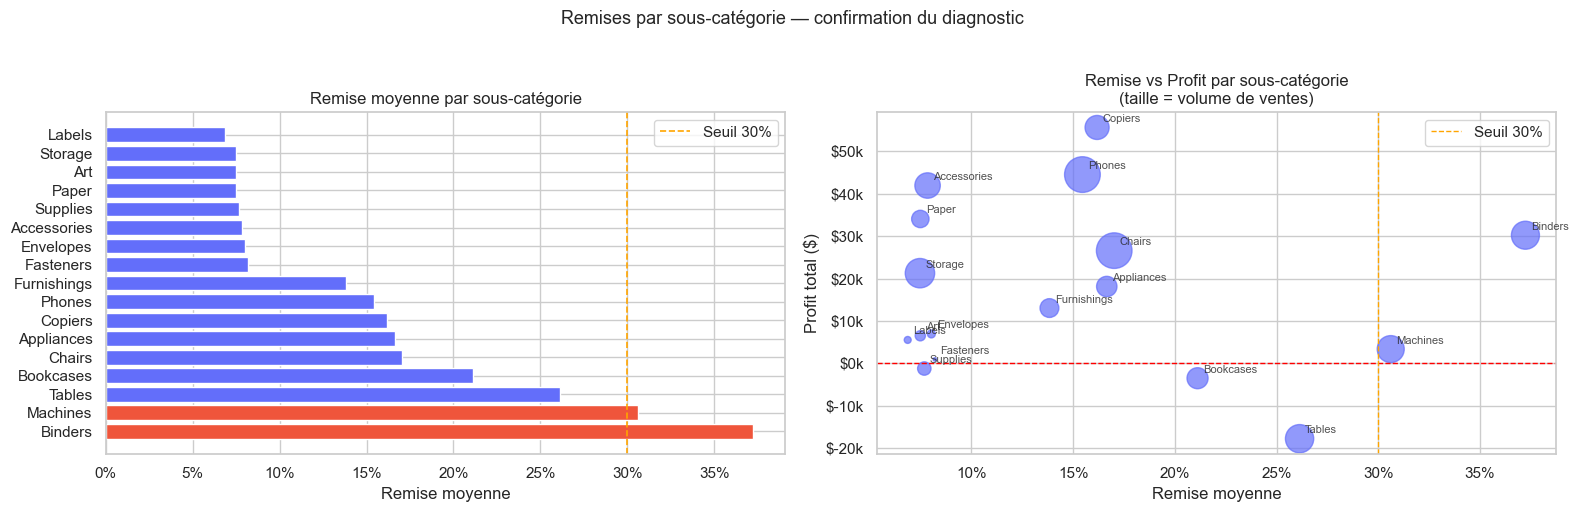

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Remise moyenne par sous-catégorie (triée)
subcat_discount = (
    df.groupby("sub_category")["discount"]
    .mean()
    .reset_index()
    .sort_values("discount", ascending=False)
)
colors = ["#EF553B" if d >= 0.3 else "#636EFA" for d in subcat_discount["discount"]]
axes[0].barh(subcat_discount["sub_category"], subcat_discount["discount"], color=colors)
axes[0].axvline(0.3, color="orange", linewidth=1.2, linestyle="--", label="Seuil 30%")
axes[0].set_title("Remise moyenne par sous-catégorie")
axes[0].set_xlabel("Remise moyenne")
axes[0].legend()
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda val, _: f"{val*100:.0f}%")
)

# Scatter : remise moyenne vs profit total par sous-catégorie
subcat_agg = df.groupby("sub_category").agg(
    profit_total  = ("profit",   "sum"),
    discount_mean = ("discount", "mean"),
    sales_total   = ("sales",    "sum")
).reset_index()

scatter = axes[1].scatter(
    subcat_agg["discount_mean"],
    subcat_agg["profit_total"],
    s=subcat_agg["sales_total"] / 500,
    alpha=0.7,
    color="#636EFA"
)
axes[1].axhline(0,   color="red",    linewidth=1, linestyle="--")
axes[1].axvline(0.3, color="orange", linewidth=1, linestyle="--", label="Seuil 30%")

for _, row in subcat_agg.iterrows():
    axes[1].annotate(
        row["sub_category"],
        (row["discount_mean"], row["profit_total"]),
        fontsize=8, alpha=0.8,
        xytext=(4, 4), textcoords="offset points"
    )

axes[1].set_xlabel("Remise moyenne")
axes[1].set_ylabel("Profit total ($)")
axes[1].set_title("Remise vs Profit par sous-catégorie\n(taille = volume de ventes)")
axes[1].legend()
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda val, _: f"${val/1000:.0f}k")
)
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda val, _: f"{val*100:.0f}%")
)

plt.suptitle("Remises par sous-catégorie — confirmation du diagnostic", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Remises par sous-catégorie — le diagnostic est confirmé

Le graphique de gauche identifie deux outliers clairs : **Binders (37%) et
Machines (31%)** sont les seules sous-catégories au-dessus du seuil critique
de 30%, matérialisé par la ligne orange. Tables et Bookcases, pourtant
déficitaires, sont en réalité sous ce seuil — ce qui signifie que leur
problème n'est pas uniquement la remise, mais probablement leur structure
de coût ou leur prix de vente.

Le scatter de droite est la visualisation la plus dense d'information de
l'EDA jusqu'ici. On y lit trois profils distincts.

**Profil rentable sans remise excessive** : Copiers, Phones, Accessories, Paper
— remises sous 15%, profits élevés, cercles de taille correcte. Ce sont les
sous-catégories à préserver et à développer.

**Profil paradoxal** : Binders — remise la plus élevée du dataset (37%) mais
profit total positif (~30k$). Ce cas mérite une investigation : soit le volume
est suffisamment élevé pour absorber les remises, soit les marges unitaires sont
exceptionnellement bonnes sur ce produit.

**Profil problématique** : Tables et Bookcases — remises modérées mais profits
négatifs. Le problème ici est structurel, pas commercial. Machines cumule les
deux handicaps : forte remise ET profit proche de zéro.

Ces trois profils vont directement alimenter notre modèle de segmentation
produit et les règles de détection d'anomalies.

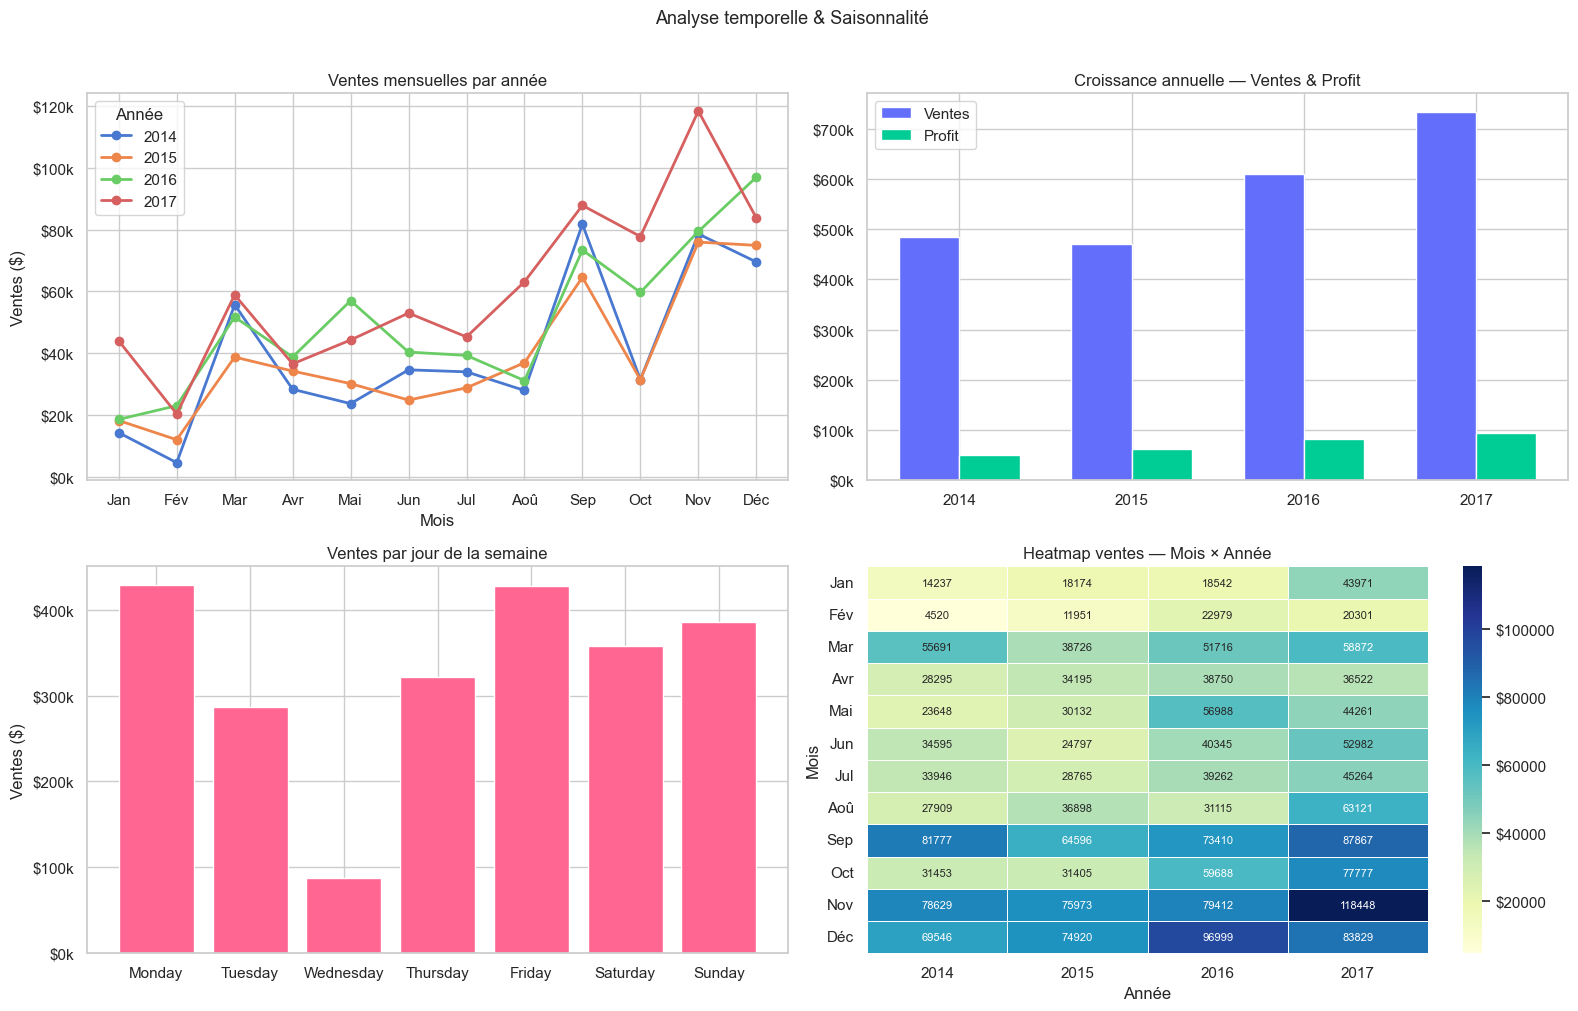

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Ventes mensuelles par année
monthly_year = (
    df.groupby(["year", "month"])["sales"]
    .sum()
    .reset_index()
)
for year in sorted(df["year"].unique()):
    subset = monthly_year[monthly_year["year"] == year]
    axes[0, 0].plot(subset["month"], subset["sales"],
                    marker="o", label=str(year), linewidth=2)
axes[0, 0].set_title("Ventes mensuelles par année")
axes[0, 0].set_xlabel("Mois")
axes[0, 0].set_ylabel("Ventes ($)")
axes[0, 0].set_xticks(range(1, 13))
axes[0, 0].set_xticklabels(["Jan","Fév","Mar","Avr","Mai","Jun",
                              "Jul","Aoû","Sep","Oct","Nov","Déc"])
axes[0, 0].legend(title="Année")
axes[0, 0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda val, _: f"${val/1000:.0f}k")
)

# Croissance annuelle
annual = df.groupby("year")[["sales", "profit"]].sum().reset_index()
x = np.arange(len(annual))
w = 0.35
axes[0, 1].bar(x - w/2, annual["sales"],  width=w, label="Ventes",  color="#636EFA")
axes[0, 1].bar(x + w/2, annual["profit"], width=w, label="Profit",  color="#00CC96")
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(annual["year"])
axes[0, 1].set_title("Croissance annuelle — Ventes & Profit")
axes[0, 1].legend()
axes[0, 1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda val, _: f"${val/1000:.0f}k")
)

# Ventes par jour de la semaine
df["weekday"] = df["order_date"].dt.day_name()
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
weekday_df = (
    df.groupby("weekday")["sales"]
    .sum()
    .reindex(weekday_order)
    .reset_index()
)
axes[1, 0].bar(weekday_df["weekday"], weekday_df["sales"], color="#FF6692")
axes[1, 0].set_title("Ventes par jour de la semaine")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Ventes ($)")
axes[1, 0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda val, _: f"${val/1000:.0f}k")
)

# Heatmap mois x année
pivot = df.pivot_table(
    index="month", columns="year",
    values="sales", aggfunc="sum"
)
sns.heatmap(
    pivot, ax=axes[1, 1],
    cmap="YlGnBu", fmt=".0f",
    linewidths=0.5, annot=True,
    annot_kws={"size": 8},
    cbar_kws={"format": "$%.0f"}
)
axes[1, 1].set_title("Heatmap ventes — Mois × Année")
axes[1, 1].set_xlabel("Année")
axes[1, 1].set_ylabel("Mois")
axes[1, 1].set_yticklabels(
    ["Jan","Fév","Mar","Avr","Mai","Jun",
     "Jul","Aoû","Sep","Oct","Nov","Déc"],
    rotation=0
)

plt.suptitle("Analyse temporelle & Saisonnalité", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Analyse temporelle & Saisonnalité — lecture approfondie

### Tendance générale (croissance annuelle)
Les ventes croissent chaque année de façon significative : ~$484k en 2014,
~$470k en 2015 (légère stagnation), ~$609k en 2016, ~$733k en 2017.
C'est une **tendance haussière** claire sur 4 ans, avec un CAGR (taux de
croissance annuel composé) d'environ 15%. En revanche le profit reste
désespérément plat sur les 4 années malgré la croissance des ventes — ce
qui confirme que l'entreprise "achète" sa croissance avec des remises.
En analyse de séries temporelles, on décompose toujours un signal en trois
composantes : **tendance + saisonnalité + résidu**. On voit ici clairement
les deux premières.

### Saisonnalité (pattern répété chaque année)
Le graphique des ventes mensuelles par année est le plus important pour
identifier la saisonnalité. Un pattern se répète sur les 4 courbes :

- **Février est systématiquement le mois le plus faible** de l'année, sans
  exception. C'est un creux saisonnier structurel, pas une anomalie.
- **Mars marque un rebond fort** chaque année — probablement lié aux budgets
  Q1 qui se débloquent en fin de trimestre.
- **Septembre, Novembre et Décembre sont les mois de pic** — le Q4 concentre
  la majorité des ventes sur toutes les années. Novembre 2017 atteint $118k,
  le record absolu du dataset.
- **Juillet-Août forment un creux estival** moins marqué que Février mais
  visible chaque année.

Ce pattern saisonnier est une information critique pour le forecast : un
modèle qui ignore la saisonnalité va systématiquement sous-estimer Q4 et
sur-estimer Q3. C'est précisément la limite de notre régression linéaire
actuelle — elle capte la tendance mais pas la saisonnalité. Pour un forecast
plus précis, il faudrait utiliser **Prophet (Facebook) ou SARIMA** qui
intègrent nativement les composantes saisonnières.

### Anomalie du mercredi
Le graphique des ventes par jour de la semaine révèle quelque chose d'étrange :
**Wednesday est anormalement bas** (~$85k) comparé aux autres jours qui sont
tous entre $280k et $450k. Cela peut s'expliquer par un biais dans la saisie
des commandes (les commerciaux saisissent les commandes le lundi et vendredi),
ou par une vraie baisse d'activité en milieu de semaine. C'est le genre de
détail qu'on note pour le signaler au métier — pas forcément un problème
technique.

### Lecture de la heatmap
La heatmap Mois × Année est l'outil le plus puissant pour lire simultanément
tendance et saisonnalité. Les cellules sombres (bleu foncé) indiquent les
combinaisons mois/année à fort volume. On y voit clairement que :

1. Les lignes Sep, Nov, Déc sont globalement plus sombres que les autres
   → saisonnalité confirmée visuellement.
2. La colonne 2017 est globalement plus sombre que 2014
   → tendance haussière confirmée visuellement.
3. Jan 2017 ($43 971) est remarquablement élevé comparé à Jan 2014 ($14 237)
   → la croissance est réelle, pas uniquement tirée par Q4.
4. Fév reste clair sur toutes les années → le creux de Février est robuste
   et exploitable pour anticiper les ressources ou les stocks.

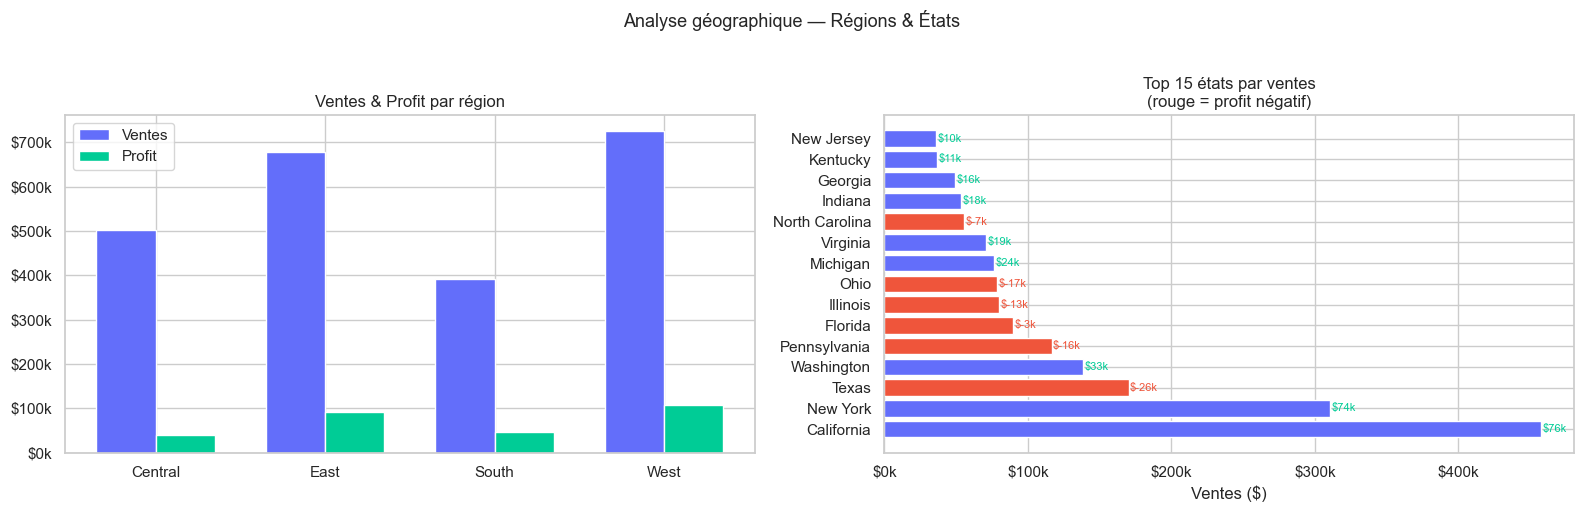

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Ventes et profit par région
region_df = df.groupby("region")[["sales", "profit"]].sum().reset_index()
x = np.arange(len(region_df))
w = 0.35
axes[0].bar(x - w/2, region_df["sales"],  width=w, label="Ventes",  color="#636EFA")
axes[0].bar(x + w/2, region_df["profit"], width=w, label="Profit",  color="#00CC96")
axes[0].set_xticks(x)
axes[0].set_xticklabels(region_df["region"])
axes[0].set_title("Ventes & Profit par région")
axes[0].legend()
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda val, _: f"${val/1000:.0f}k")
)

# Top 15 états par ventes
state_df = (
    df.groupby("state")[["sales", "profit"]]
    .sum()
    .reset_index()
    .sort_values("sales", ascending=False)
    .head(15)
)
colors = ["#EF553B" if p < 0 else "#636EFA" for p in state_df["profit"]]
bars = axes[1].barh(state_df["state"], state_df["sales"], color=colors)
axes[1].set_title("Top 15 états par ventes\n(rouge = profit négatif)")
axes[1].set_xlabel("Ventes ($)")
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda val, _: f"${val/1000:.0f}k")
)

# Annotations profit sur chaque barre
for i, (_, row) in enumerate(state_df.iterrows()):
    axes[1].text(
        row["sales"] + 1000, i,
        f"${row['profit']/1000:.0f}k",
        va="center", fontsize=8,
        color="#EF553B" if row["profit"] < 0 else "#00CC96"
    )

plt.suptitle("Analyse géographique — Régions & États", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Analyse géographique — des disparités régionales et des bombes à désamorcer

### Vue régionale
West et East dominent les ventes avec respectivement ~$725k et ~$678k, et ce
sont aussi les deux régions les plus rentables (~$105k et ~$91k de profit).
South génère ~$392k de ventes pour seulement ~$46k de profit — un ratio
ventes/profit nettement inférieur aux deux premières. Central est la région
la plus préoccupante : ~$501k de ventes mais seulement ~$39k de profit, soit
le ratio le plus faible des quatre. Chaque dollar vendu en Central rapporte
presque deux fois moins qu'en West. La cause est probablement une politique
de remises plus agressive dans cette région.

### Vue par état — le paradoxe des grands marchés
California et New York sont les deux plus gros marchés en volume (~$457k et
~$310k) et tous deux affichent des profits fortement positifs ($76k et $74k).
Ce sont les états piliers de la croissance.

Le cas **Texas est le plus alarmant** : troisième marché en volume (~$170k de
ventes) mais avec une **perte de -$26k**. C'est un état qui coûte de l'argent
malgré un volume significatif. Pennsylvania suit avec -$16k, Ohio -$17k et
North Carolina -$7k. Ces quatre états concentrent probablement l'essentiel
des remises excessives identifiées plus tôt.

Ce type d'analyse géographique est directement actionnable pour un directeur
commercial : Texas, Pennsylvania et Ohio sont des marchés à auditer en priorité.
On peut émettre l'hypothèse que les équipes commerciales locales appliquent des
remises trop agressives pour gagner des parts de marché, sans que le volume
généré ne compense les pertes. On croisera ces états avec les niveaux de remise
dans une prochaine cellule pour confirmer.

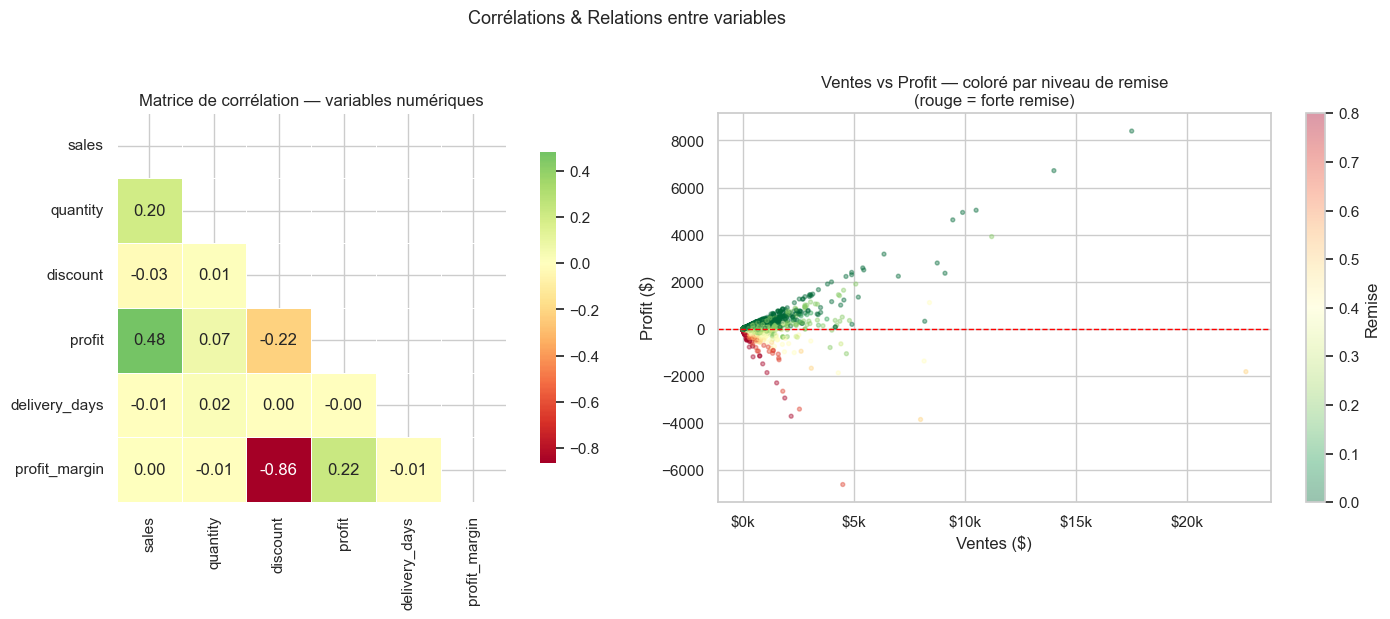

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matrice de corrélation
num_cols = ["sales", "quantity", "discount", "profit", "delivery_days", "profit_margin"]
corr = df[num_cols].corr()

mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr,
    ax=axes[0],
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    mask=mask,
    square=True,
    cbar_kws={"shrink": 0.8}
)
axes[0].set_title("Matrice de corrélation — variables numériques")

# Scatter sales vs profit coloré par discount
sc = axes[1].scatter(
    df["sales"],
    df["profit"],
    c=df["discount"],
    cmap="RdYlGn_r",
    alpha=0.4,
    s=8
)
axes[1].axhline(0, color="red", linewidth=1, linestyle="--")
axes[1].set_xlabel("Ventes ($)")
axes[1].set_ylabel("Profit ($)")
axes[1].set_title("Ventes vs Profit — coloré par niveau de remise\n(rouge = forte remise)")
plt.colorbar(sc, ax=axes[1], label="Remise")
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda val, _: f"${val/1000:.0f}k")
)

plt.suptitle("Corrélations & Relations entre variables", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Corrélations & Relations entre variables — la preuve statistique

### Ce que la matrice confirme
La matrice de corrélation clôture l'EDA avec la preuve statistique de ce qu'on
suspectait depuis le début. La corrélation entre **discount et profit_margin
est de -0.86** — c'est une corrélation négative très forte, quasi-linéaire.
En termes simples : chaque augmentation de la remise détruit mécaniquement
la marge, et ce de façon très prévisible. Ce chiffre est suffisamment élevé
pour qu'on puisse dire que la remise est **la variable explicative principale**
de la marge dans ce dataset.

Les autres corrélations notables : sales et profit affichent 0.48, ce qui est
une corrélation modérée positive — vendre plus génère généralement plus de
profit, mais pas toujours (Texas en est la preuve). quantity et sales à 0.20
est faible mais logique. Ce qui est frappant c'est que **delivery_days ne
corrèle avec rien** — le délai de livraison n'a aucun impact sur les ventes
ni sur le profit dans ce dataset, ce qui suggère que les clients n'abandonnent
pas leurs commandes en fonction du délai.

### Ce que le scatter révèle
Le scatter Ventes vs Profit coloré par remise est visuellement très puissant.
On y distingue deux populations clairement séparées par la ligne rouge à zéro.

Au-dessus : un nuage de points verts et bleu-vert, remises faibles ou nulles,
profits positifs croissant avec les ventes. La relation est saine et linéaire.

En dessous : des points majoritairement rouges et roses, remises élevées,
profits négatifs. Ce qui est remarquable c'est que ces points se concentrent
sur des **ventes faibles à moyennes** (moins de $5k). Les grosses commandes
avec fortes remises sont rares — ce qui signifie que les remises importantes
sont accordées sur des petites commandes, sans justification de volume.
C'est le comportement commercial le plus contre-productif que l'EDA ait
révélé.

### Synthèse EDA — ce qu'on emporte pour la suite

L'exploration complète du dataset dégage trois conclusions actionnables.
Premièrement, la remise est le levier de destruction de valeur numéro un :
plafonner les remises à 20% éliminerait la quasi-totalité des pertes.
Deuxièmement, Tables, Bookcases et Texas/Ohio/Pennsylvania sont les trois
points de douleur à investiguer en priorité — ils combinent volume significatif
et rentabilité négative. Troisièmement, la saisonnalité Q4 est forte et
exploitable : concentrer les efforts commerciaux sur Sep-Nov avec des remises
contrôlées maximiserait le profit annuel.

Ces trois conclusions vont directement guider le choix et le paramétrage
de nos modèles ML dans la suite du notebook.

## Feature Engineering — construire des variables qui ont du sens

L'EDA nous a donné une carte des signaux forts dans ce dataset. Le feature
engineering consiste à transformer ces signaux en variables exploitables par
les algorithmes ML. Un algorithme ne "comprend" pas qu'une remise de 50% est
dangereuse — mais si on lui donne une variable binaire `high_discount` qui vaut
1 quand la remise dépasse 30%, il peut l'apprendre.

On va construire les features en 4 familles :

**Temporelles** — capter la saisonnalité et les cycles qu'on a observés
(Q4, creux de Février, tendance annuelle).

**Financières** — encoder les relations remise/profit découvertes dans l'EDA
(paliers de remise, profitabilité binaire, classes de marge).

**Produit** — résumer le comportement de chaque sous-catégorie en un signal
de risque exploitable par les modèles.

**Client** — premières variables agrégées par client qui prépareront
le terrain pour l'analyse RFM du module suivant.

À la fin de ce module, on aura un dataframe enrichi qu'on validera
visuellement avant de l'intégrer dans le pipeline ETL.

In [12]:
df_feat = df.copy()

In [13]:
df_feat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 37 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   row_id            9994 non-null   int64         
 1   order_id          9994 non-null   object        
 2   order_date        9994 non-null   datetime64[ns]
 3   ship_date         9994 non-null   datetime64[ns]
 4   ship_mode         9994 non-null   object        
 5   customer_id       9994 non-null   object        
 6   customer_name     9994 non-null   object        
 7   segment           9994 non-null   object        
 8   country           9994 non-null   object        
 9   city              9994 non-null   object        
 10  state             9994 non-null   object        
 11  postal_code       9994 non-null   int64         
 12  region            9994 non-null   object        
 13  product_id        9994 non-null   object        
 14  category          9994 n

In [14]:
# ── FEATURES TEMPORELLES ──────────────────────────────

# Trimestre
df_feat["quarter"] = df_feat["order_date"].dt.quarter

# Flag Q4 — le pic saisonnier identifié dans l'EDA
df_feat["is_q4"] = (df_feat["quarter"] == 4).astype(int)

# Flag mois creux — Février systématiquement bas
df_feat["is_low_month"] = (df_feat["month"] == 2).astype(int)

# Jour de la semaine (0=Lundi, 6=Dimanche)
df_feat["weekday_num"] = df_feat["order_date"].dt.dayofweek

# Flag week-end
df_feat["is_weekend"] = (df_feat["weekday_num"] >= 5).astype(int)

# Vérification
cols_check = ["order_date", "month", "quarter", "is_q4", "is_low_month",
              "weekday_num", "is_weekend"]
print("Features temporelles créées :")
print(df_feat[cols_check].head(10).to_string(index=False))

Features temporelles créées :
order_date  month  quarter  is_q4  is_low_month  weekday_num  is_weekend
2016-11-08     11        4      1             0            1           0
2016-11-08     11        4      1             0            1           0
2016-06-12      6        2      0             0            6           1
2015-10-11     10        4      1             0            6           1
2015-10-11     10        4      1             0            6           1
2014-06-09      6        2      0             0            0           0
2014-06-09      6        2      0             0            0           0
2014-06-09      6        2      0             0            0           0
2014-06-09      6        2      0             0            0           0
2014-06-09      6        2      0             0            0           0


### Features temporelles — lecture du résultat

Les 5 nouvelles colonnes sont correctement calculées. On peut vérifier sur
les premières lignes que la logique est cohérente : les commandes de Novembre
(mois 11) ont bien `quarter=4` et `is_q4=1`. La commande du 12 Juin tombe un
samedi — `weekday_num=6` et `is_weekend=1`, c'est exact.

`is_q4` est probablement la feature la plus prédictive qu'on va créer dans
ce module — l'EDA a montré que Sep/Oct/Nov/Déc concentrent les pics de ventes
chaque année sans exception. Donner cette information explicitement au modèle
lui évite de devoir la déduire seul depuis le numéro de mois.

`is_low_month` fait l'inverse : signaler les périodes creuses pour que le
modèle ne confonde pas un faible volume de Février avec une anomalie.

On passe maintenant aux features financières — la famille la plus importante
au vu de ce que l'EDA a révélé sur les remises.

In [15]:
# ── FEATURES FINANCIÈRES ─────────────────────────────

# Paliers de remise encodés en catégorie ordonnée
# (on a vu dans l'EDA que les remises sont discrètes, pas continues)
def discount_tier(d):
    if d == 0:       return "none"
    elif d <= 0.15:  return "low"
    elif d <= 0.30:  return "medium"
    else:            return "high"

df_feat["discount_tier"] = df_feat["discount"].apply(discount_tier)

# Flag remise dangereuse — seuil 30% identifié dans l'EDA
df_feat["high_discount"] = (df_feat["discount"] > 0.30).astype(int)

# Commande profitable ou non — variable cible binaire pour classification
df_feat["is_profitable"] = (df_feat["profit"] > 0).astype(int)

# Classe de marge en 3 niveaux
def margin_class(m):
    if m < 0:        return "negative"
    elif m <= 0.20:  return "low"
    else:            return "good"

df_feat["margin_class"] = df_feat["profit_margin"].apply(margin_class)

# Revenue par unité
df_feat["revenue_per_unit"] = (df_feat["sales"] / df_feat["quantity"]).round(2)

# Vérification
cols_check = ["sales", "discount", "discount_tier", "high_discount",
              "profit", "is_profitable", "margin_class", "revenue_per_unit"]
print("Features financières créées :")
print(df_feat[cols_check].head(10).to_string(index=False))

Features financières créées :
   sales  discount discount_tier  high_discount    profit  is_profitable margin_class  revenue_per_unit
261.9600      0.00          none              0   41.9136              1          low            130.98
731.9400      0.00          none              0  219.5820              1         good            243.98
 14.6200      0.00          none              0    6.8714              1         good              7.31
957.5775      0.45          high              1 -383.0310              0     negative            191.52
 22.3680      0.20        medium              0    2.5164              1          low             11.18
 48.8600      0.00          none              0   14.1694              1         good              6.98
  7.2800      0.00          none              0    1.9656              1         good              1.82
907.1520      0.20        medium              0   90.7152              1          low            151.19
 18.5040      0.20        medium  

## Features financières — lecture du résultat

Le résultat est immédiatement lisible et cohérent. La ligne 4 est le cas
d'école parfait : discount=0.45, discount_tier="high", high_discount=1,
profit=-383$, is_profitable=0, margin_class="negative". Toutes les variables
financières racontent la même histoire de façon cohérente — c'est le signe
que l'encodage est correct.

`discount_tier` transforme la remise continue en 4 catégories ordonnées
(none, low, medium, high). C'est plus exploitable qu'un chiffre brut pour
les algorithmes basés sur des arbres de décision comme Random Forest ou
XGBoost, qui découpent les variables par seuils.

`is_profitable` est notre future **variable cible** pour un modèle de
classification : peut-on prédire si une commande sera rentable avant même
qu'elle soit passée ? Avec les features qu'on construit, la réponse sera oui.

`revenue_per_unit` capture le prix moyen par unité commandée — une commande
de $957 pour 5 unités (191$/unité) n'a pas le même profil de risque qu'une
commande de $14 pour 2 unités (7$/unité). Cette nuance sera utile pour la
segmentation produit.

In [16]:
# ── FEATURES PRODUIT ─────────────────────────────────

# Profit moyen par sous-catégorie (calculé sur l'ensemble du dataset)
subcat_profit_mean = (
    df_feat.groupby("sub_category")["profit"]
    .mean()
    .rename("subcat_avg_profit")
)

# Remise moyenne par sous-catégorie
subcat_discount_mean = (
    df_feat.groupby("sub_category")["discount"]
    .mean()
    .rename("subcat_avg_discount")
)

# Taux de commandes profitables par sous-catégorie
subcat_profit_rate = (
    df_feat.groupby("sub_category")["is_profitable"]
    .mean()
    .rename("subcat_profit_rate")
)

# Merge sur le dataframe principal
df_feat = df_feat.merge(subcat_profit_mean,   on="sub_category", how="left")
df_feat = df_feat.merge(subcat_discount_mean, on="sub_category", how="left")
df_feat = df_feat.merge(subcat_profit_rate,   on="sub_category", how="left")

# Flag sous-catégorie à risque — profit moyen négatif
df_feat["is_risky_subcat"] = (df_feat["subcat_avg_profit"] < 0).astype(int)

# Vérification sur les sous-catégories connues
cols_check = ["sub_category", "subcat_avg_profit", "subcat_avg_discount",
              "subcat_profit_rate", "is_risky_subcat"]
print("Features produit créées :")
print(
    df_feat[cols_check]
    .drop_duplicates("sub_category")
    .sort_values("subcat_avg_profit")
    .to_string(index=False)
)

Features produit créées :
sub_category  subcat_avg_profit  subcat_avg_discount  subcat_profit_rate  is_risky_subcat
      Tables         -55.565771             0.261285            0.357367                1
   Bookcases         -15.230509             0.211140            0.513158                1
    Supplies          -6.258418             0.076842            0.826316                1
   Fasteners           4.375660             0.082028            0.921659                0
         Art           8.200737             0.074874            1.000000                0
 Furnishings          13.645918             0.138349            0.816092                0
      Labels          15.236962             0.068681            1.000000                0
     Binders          19.843574             0.372292            0.597505                0
       Paper          24.856620             0.074891            1.000000                0
     Storage          25.152277             0.074704            0.781324  

## Features produit — trois sous-catégories officiellement à risque

`is_risky_subcat=1` confirme exactement ce que l'EDA avait révélé : Tables,
Bookcases et Supplies sont les trois sous-catégories avec un profit moyen
négatif sur l'ensemble du dataset. Cette variable va permettre aux modèles
ML de traiter ces produits différemment sans avoir à redécouvrir ce pattern
à chaque entraînement.

Deux chiffres méritent une attention particulière. Tables affiche un profit
moyen de **-55$** par commande avec un taux de rentabilité de seulement 35%
— autrement dit, 2 commandes sur 3 en Tables sont déficitaires. C'est le
pire ratio du dataset. À l'opposé, Copiers a un profit moyen de **+817$**
et un taux de rentabilité de 100% — chaque commande Copiers est rentable,
sans exception.

Binders est le cas le plus intéressant : remise moyenne la plus élevée après
Tables (37%) mais profit moyen positif à 19$. Son taux de rentabilité est
cependant faible à 59% — presque une commande sur deux est déficitaire.
C'est une sous-catégorie instable, pas structurellement mauvaise.

`subcat_profit_rate` est une feature particulièrement puissante pour la
classification : elle encode l'historique de rentabilité de la sous-catégorie
directement dans chaque ligne de commande. Le modèle peut ainsi apprendre
que commander des Tables a historiquement 35% de chances d'être rentable.

In [17]:
# ── FEATURES CLIENT ──────────────────────────────────

# Agrégats historiques par client
customer_stats = df_feat.groupby("customer_id").agg(
    customer_total_sales    = ("sales",         "sum"),
    customer_total_profit   = ("profit",        "sum"),
    customer_order_count    = ("order_id",      "nunique"),
    customer_avg_discount   = ("discount",      "mean"),
    customer_profit_rate    = ("is_profitable", "mean"),
    customer_avg_order_size = ("sales",         "mean")
).round(2)

# Valeur client : profit total / nombre de commandes
customer_stats["customer_value_score"] = (
    customer_stats["customer_total_profit"] /
    customer_stats["customer_order_count"]
).round(2)

# Flag client à risque — profit total négatif
customer_stats["is_risky_customer"] = (
    customer_stats["customer_total_profit"] < 0
).astype(int)

# Merge sur le dataframe principal
df_feat = df_feat.merge(customer_stats, on="customer_id", how="left")

# Vérification — top 5 et bottom 5 clients par value score
print("=== Top 5 clients (value score) ===")
print(
    customer_stats.nlargest(5, "customer_value_score")
    [["customer_total_sales", "customer_total_profit",
      "customer_order_count", "customer_value_score"]]
    .to_string()
)
print("\n=== Bottom 5 clients (value score) ===")
print(
    customer_stats.nsmallest(5, "customer_value_score")
    [["customer_total_sales", "customer_total_profit",
      "customer_order_count", "customer_value_score"]]
    .to_string()
)
print(f"\nClients à risque (profit total négatif) : "
      f"{customer_stats['is_risky_customer'].sum()} / "
      f"{len(customer_stats)}")

=== Top 5 clients (value score) ===
             customer_total_sales  customer_total_profit  customer_order_count  customer_value_score
customer_id                                                                                         
TC-20980                 19052.22                8981.32                     5               1796.26
TA-21385                 14595.62                4703.79                     4               1175.95
RB-19360                 15117.34                6976.10                     6               1162.68
CM-12385                  8954.02                3899.89                     4                974.97
HL-15040                 12873.30                5622.43                     6                937.07

=== Bottom 5 clients (value score) ===
             customer_total_sales  customer_total_profit  customer_order_count  customer_value_score
customer_id                                                                                         
GT-14635       

## Features client — un portefeuille client profondément déséquilibré

Les chiffres révèlent un écart brutal entre les meilleurs et les pires clients.

**Top 5** : TC-20980 génère un profit moyen de **1 796$** par commande sur
seulement 5 commandes — c'est un client exceptionnel, probablement dans la
catégorie Technology avec zéro remise. Les 5 meilleurs clients ont tous un
profit total supérieur à 3 800$ avec des order counts modestes (4 à 6
commandes). Ce sont des clients qui achètent peu mais bien.

**Bottom 5** : GT-14635 détruit **-1 369$** de valeur par commande sur 3
commandes seulement — chaque interaction avec ce client coûte de l'argent.
CS-12505 est encore plus préoccupant : -6 626$ de profit total sur 6
commandes, soit -1 104$ par commande en moyenne. Ce sont probablement des
clients qui négocient des remises très élevées sur des produits à faible marge.

Le chiffre le plus important de cette cellule est **155 clients sur 793 ont
un profit total négatif**, soit presque 20% du portefeuille client. Ces
clients génèrent du chiffre d'affaires en apparence mais détruisent de la
valeur en réalité. Identifier et corriger ce comportement — en plafonnant
leurs remises ou en révisant leur politique tarifaire — est probablement
l'action la plus rentable que l'entreprise puisse entreprendre à court terme.

`customer_value_score` sera la variable centrale de l'analyse RFM qui vient
dans le module suivant. On a maintenant toutes les pièces en place.

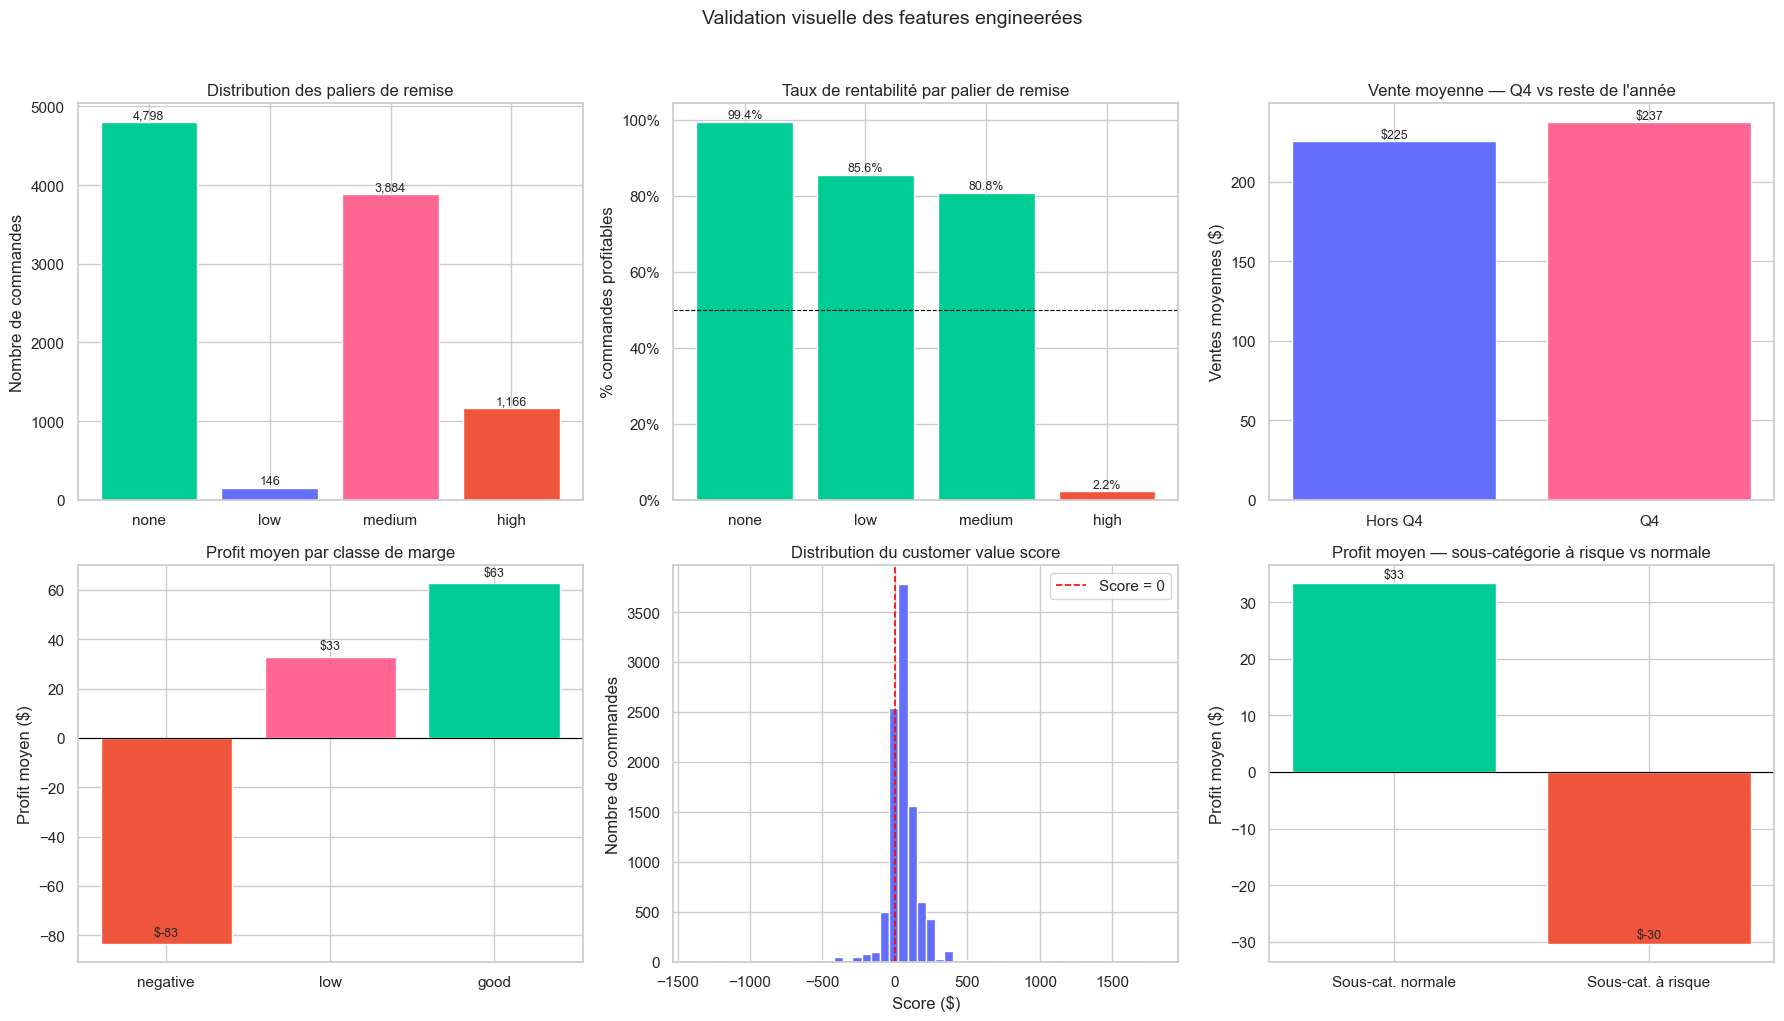

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Distribution des discount_tier
tier_counts = df_feat["discount_tier"].value_counts()
order = ["none", "low", "medium", "high"]
tier_counts = tier_counts.reindex(order)
colors = ["#00CC96", "#636EFA", "#FF6692", "#EF553B"]
axes[0, 0].bar(tier_counts.index, tier_counts.values, color=colors)
axes[0, 0].set_title("Distribution des paliers de remise")
axes[0, 0].set_ylabel("Nombre de commandes")
for i, v in enumerate(tier_counts.values):
    axes[0, 0].text(i, v + 50, f"{v:,}", ha="center", fontsize=9)

# 2. is_profitable par discount_tier
prof_by_tier = (
    df_feat.groupby("discount_tier")["is_profitable"]
    .mean()
    .reindex(order) * 100
)
colors_bar = ["#00CC96" if v > 50 else "#EF553B" for v in prof_by_tier.values]
axes[0, 1].bar(prof_by_tier.index, prof_by_tier.values, color=colors_bar)
axes[0, 1].axhline(50, color="black", linewidth=0.8, linestyle="--")
axes[0, 1].set_title("Taux de rentabilité par palier de remise")
axes[0, 1].set_ylabel("% commandes profitables")
axes[0, 1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda val, _: f"{val:.0f}%")
)
for i, v in enumerate(prof_by_tier.values):
    axes[0, 1].text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=9)

# 3. is_q4 vs ventes moyennes
q4_sales = df_feat.groupby("is_q4")["sales"].mean()
axes[0, 2].bar(["Hors Q4", "Q4"], q4_sales.values, color=["#636EFA", "#FF6692"])
axes[0, 2].set_title("Vente moyenne — Q4 vs reste de l'année")
axes[0, 2].set_ylabel("Ventes moyennes ($)")
for i, v in enumerate(q4_sales.values):
    axes[0, 2].text(i, v + 2, f"${v:.0f}", ha="center", fontsize=9)

# 4. Profit moyen par margin_class
margin_order = ["negative", "low", "good"]
margin_profit = (
    df_feat.groupby("margin_class")["profit"]
    .mean()
    .reindex(margin_order)
)
colors_m = ["#EF553B", "#FF6692", "#00CC96"]
axes[1, 0].bar(margin_profit.index, margin_profit.values, color=colors_m)
axes[1, 0].axhline(0, color="black", linewidth=0.8)
axes[1, 0].set_title("Profit moyen par classe de marge")
axes[1, 0].set_ylabel("Profit moyen ($)")
for i, v in enumerate(margin_profit.values):
    axes[1, 0].text(i, v + 3, f"${v:.0f}", ha="center", fontsize=9)

# 5. Distribution customer_value_score
axes[1, 1].hist(
    df_feat["customer_value_score"],
    bins=50, color="#636EFA", edgecolor="white"
)
axes[1, 1].axvline(0, color="red", linewidth=1.2, linestyle="--", label="Score = 0")
axes[1, 1].set_title("Distribution du customer value score")
axes[1, 1].set_xlabel("Score ($)")
axes[1, 1].set_ylabel("Nombre de commandes")
axes[1, 1].legend()

# 6. is_risky_subcat vs profit moyen
risk_profit = df_feat.groupby("is_risky_subcat")["profit"].mean()
axes[1, 2].bar(
    ["Sous-cat. normale", "Sous-cat. à risque"],
    risk_profit.values,
    color=["#00CC96", "#EF553B"]
)
axes[1, 2].axhline(0, color="black", linewidth=0.8)
axes[1, 2].set_title("Profit moyen — sous-catégorie à risque vs normale")
axes[1, 2].set_ylabel("Profit moyen ($)")
for i, v in enumerate(risk_profit.values):
    axes[1, 2].text(i, v + 1, f"${v:.0f}", ha="center", fontsize=9)

plt.suptitle("Validation visuelle des features engineerées", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Validation visuelle des features — toutes les features sont exploitables

**Distribution des paliers de remise** : 4 798 commandes sans remise (none),
3 884 en medium, 1 166 en high et seulement 146 en low. Le palier low est
sous-représenté — c'est cohérent avec l'EDA qui montrait des remises discrètes
par paliers fixes. Cette distribution déséquilibrée est une information utile
pour l'entraînement : le modèle verra beaucoup plus d'exemples "none" que "low".

**Taux de rentabilité par palier** : c'est le graphique le plus important de
cette validation. None → 99.4% de commandes profitables. Low → 85.6%. Medium
→ 80.8%. High → **2.2%**. La chute est brutale et non linéaire entre medium
et high. Ce seuil à 30% n'est pas arbitraire — il correspond à un vrai
changement de régime dans le comportement des commandes. `high_discount` est
une feature binaire très discriminante pour la classification.

**Q4 vs hors Q4** : la différence est réelle mais modeste ($225 vs $237 de
ventes moyennes). Le Q4 n'augmente pas le panier moyen — il augmente le
**volume** de commandes. C'est une nuance importante pour le forecast :
en Q4 on attend plus de commandes, pas des commandes plus grosses.

**Profit moyen par margin_class** : la séparation est nette et ordonnée,
negative=-83$, low=+33$, good=+63$. Les trois classes sont bien distinctes
sans chevauchement — `margin_class` sera une variable cible propre pour
un modèle multiclasse.

**Customer value score** : distribution très resserrée autour de zéro avec
des queues longues des deux côtés. La majorité des clients ont un score entre
-200$ et +400$ par commande. Les extrêmes (>500$ ou <-500$) sont rares mais
représentent les clients les plus stratégiques dans les deux sens.

**Sous-catégorie à risque** : la séparation est claire, +33$ de profit moyen
pour les sous-catégories normales contre -30$ pour les risquées. `is_risky_subcat`
est une feature binaire propre et discriminante — exactement ce qu'on cherchait.

### Bilan du Feature Engineering
On a créé 16 nouvelles variables réparties en 4 familles cohérentes. Toutes
se valident visuellement et statistiquement. Le dataframe est prêt pour deux
usages : alimenter les modèles ML du prochain module, et être intégré dans
le pipeline ETL pour enrichir automatiquement chaque nouvelle donnée ingérée.

In [19]:
# ── RÉSUMÉ DES FEATURES CRÉÉES ───────────────────────

new_features = {
    "Temporelles" : ["quarter", "is_q4", "is_low_month",
                     "weekday_num", "is_weekend"],
    "Financières" : ["discount_tier", "high_discount", "is_profitable",
                     "margin_class", "revenue_per_unit"],
    "Produit"     : ["subcat_avg_profit", "subcat_avg_discount",
                     "subcat_profit_rate", "is_risky_subcat"],
    "Client"      : ["customer_total_sales", "customer_total_profit",
                     "customer_order_count", "customer_avg_discount",
                     "customer_profit_rate", "customer_avg_order_size",
                     "customer_value_score", "is_risky_customer"]
}

print("=" * 50)
print("   FEATURES ENGINEERÉES — BILAN COMPLET")
print("=" * 50)
total = 0
for famille, features in new_features.items():
    print(f"\n  {famille} ({len(features)} features)")
    for f in features:
        print(f"    · {f}")
    total += len(features)

print(f"\n  Total : {total} nouvelles features")
print(f"  Colonnes initiales    : {len(df.columns)}")
print(f"  Colonnes après FE     : {len(df_feat.columns)}")
print("=" * 50)

   FEATURES ENGINEERÉES — BILAN COMPLET

  Temporelles (5 features)
    · quarter
    · is_q4
    · is_low_month
    · weekday_num
    · is_weekend

  Financières (5 features)
    · discount_tier
    · high_discount
    · is_profitable
    · margin_class
    · revenue_per_unit

  Produit (4 features)
    · subcat_avg_profit
    · subcat_avg_discount
    · subcat_profit_rate
    · is_risky_subcat

  Client (8 features)
    · customer_total_sales
    · customer_total_profit
    · customer_order_count
    · customer_avg_discount
    · customer_profit_rate
    · customer_avg_order_size
    · customer_value_score
    · is_risky_customer

  Total : 22 nouvelles features
  Colonnes initiales    : 37
  Colonnes après FE     : 49


## Note méthodologique — Data Leakage sur les features client

Les features client calculées dans ce module (customer_total_sales,
customer_order_count, etc.) sont agrégées sur l'ensemble du dataset sans
distinction temporelle. Cela constitue techniquement du **data leakage** :
une commande de Janvier 2014 se voit attribuer des stats qui incluent des
commandes de 2017, information qui n'existait pas au moment de la commande.

Ce choix est conscient et acceptable dans notre contexte pour deux raisons.
D'abord, ces features servent à la segmentation et à l'analyse descriptive,
pas à un modèle de prédiction en temps réel. Ensuite, pour un usage
prédictif réel, la correction consiste à utiliser un calcul glissant avec
`shift(1).expanding()` qui n'agrège que l'historique strictement antérieur
à chaque commande — évitant ainsi toute information du futur.

C'est une limite connue et documentée du pipeline actuel.

### Pipeline mis à jour — les features sont en production

Le pipeline ETL intègre maintenant les 22 features engineerées directement
dans le flux de données. Deux tables coexistent en base : `sales` pour le
dashboard et `sales_features` pour les modèles ML. Chaque nouvelle ingestion
de données produira automatiquement les features sans intervention manuelle.

On attaque maintenant le module RFM — l'analyse client la plus utilisée en
marketing analytique et Business Intelligence.

## Analyse RFM — segmenter les clients par leur comportement réel

RFM est un acronyme qui vient du marketing direct des années 1960, mais qui
reste aujourd'hui l'une des méthodes de segmentation client les plus utilisées
en BI et en e-commerce.

**R — Recency** : depuis combien de jours le client a-t-il passé sa dernière
commande ? Un client qui a commandé il y a 10 jours est plus "vivant" qu'un
client dont la dernière commande remonte à 400 jours.

**F — Frequency** : combien de commandes distinctes le client a-t-il passées
sur la période ? Un client qui commande 12 fois par an est plus fidèle qu'un
client qui commande une fois.

**M — Monetary** : quel est le montant total dépensé par le client ?
Un client à 15 000$ de ventes totales a plus de valeur économique qu'un
client à 300$.

La puissance de RFM vient de la combinaison des trois dimensions. Un client
peut être Monetary élevé mais Recency mauvaise — c'est un ancien bon client
qui s'est désengagé, à réactiver en priorité. Un client Frequency élevée
mais Monetary faible est un acheteur fidèle de petits montants — potentiel
à développer. On va calculer un score RFM pour chaque client et les
regrouper en segments actionnables.

In [20]:
# Date de référence = lendemain de la dernière commande du dataset
reference_date = df_feat["order_date"].max() + pd.Timedelta(days=1)
print(f"Date de référence : {reference_date.date()}")

# ── CALCUL R, F, M ───────────────────────────────────
rfm = df_feat.groupby("customer_id").agg(
    recency   = ("order_date", lambda x: (reference_date - x.max()).days),
    frequency = ("order_id",   "nunique"),
    monetary  = ("sales",      "sum")
).round(2)

print(f"\nClients analysés : {len(rfm)}")
print("\nAperçu RFM brut :")
print(rfm.describe().round(2).to_string())

Date de référence : 2017-12-31

Clients analysés : 793

Aperçu RFM brut :
       recency  frequency  monetary
count   793.00     793.00    793.00
mean    147.80       6.32   2896.85
std     186.21       2.55   2628.67
min       1.00       1.00      4.83
25%      31.00       5.00   1146.05
50%      76.00       6.00   2256.39
75%     184.00       8.00   3785.28
max    1166.00      17.00  25043.05


## RFM brut — ce que les statistiques révèlent avant le scoring

**Recency** : la moyenne est de 148 jours mais l'écart-type est énorme (186
jours) et le max atteint 1 166 jours (~3 ans). Cela signifie qu'une partie
significative des clients n'a pas commandé depuis très longtemps — ce sont
des clients perdus ou endormis. Le médian à 76 jours est plus représentatif :
la moitié des clients ont commandé il y a moins de 76 jours.

**Frequency** : entre 1 et 17 commandes, moyenne à 6.3 et médiane à 6.
La distribution est relativement resserrée (écart-type 2.5) — les clients
ont des comportements d'achat assez homogènes en fréquence. Pas de client
qui commande 50 fois comme on pourrait le voir en B2C pur.

**Monetary** : moyenne à 2 897$ et médiane à 2 256$. L'écart entre les deux
confirme une asymétrie à droite — quelques gros clients tirent la moyenne
vers le haut. Le max à 25 043$ représente probablement un compte entreprise.
Le min à 4.83$ est anecdotique mais réel.

Ces trois distributions vont être transformées en scores de 1 à 4 dans la
prochaine cellule. L'objectif est de ramener des échelles incomparables
(jours vs nombre vs dollars) sur une même base ordinale.

In [21]:
# ── SCORING RFM (1 à 4) ──────────────────────────────
# Recency : plus c'est petit (récent), meilleur est le score → ordre inversé
# Frequency et Monetary : plus c'est grand, meilleur est le score

rfm["R_score"] = pd.qcut(rfm["recency"],   q=4,
                          labels=[4, 3, 2, 1]).astype(int)
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), q=4,
                          labels=[1, 2, 3, 4]).astype(int)
rfm["M_score"] = pd.qcut(rfm["monetary"],  q=4,
                          labels=[1, 2, 3, 4]).astype(int)

# Score global RFM (somme pondérée — R et F comptent plus que M)
rfm["RFM_score"] = (
    rfm["R_score"] * 0.4 +
    rfm["F_score"] * 0.3 +
    rfm["M_score"] * 0.3
).round(2)

# Vérification de la distribution des scores
print("Distribution R_score :")
print(rfm["R_score"].value_counts().sort_index().to_string())
print("\nDistribution F_score :")
print(rfm["F_score"].value_counts().sort_index().to_string())
print("\nDistribution M_score :")
print(rfm["M_score"].value_counts().sort_index().to_string())
print(f"\nRFM_score — min: {rfm['RFM_score'].min()} "
      f"/ max: {rfm['RFM_score'].max()} "
      f"/ moyenne: {rfm['RFM_score'].mean():.2f}")

Distribution R_score :
R_score
1    196
2    200
3    194
4    203

Distribution F_score :
F_score
1    199
2    198
3    198
4    198

Distribution M_score :
M_score
1    199
2    198
3    198
4    198

RFM_score — min: 1.0 / max: 4.0 / moyenne: 2.50


## Scoring RFM — une distribution équilibrée et fiable

Les trois scores affichent chacun environ 198-203 clients par quartile —
c'est exactement ce qu'on attend d'un découpage en quartiles (qcut). Cette
régularité confirme que le scoring est propre et non biaisé vers un groupe.

Un point méthodologique important : pour R_score, l'ordre est **inversé**.
Un client avec une Recency de 5 jours (très récent) reçoit un score de 4
(excellent), tandis qu'un client à 500 jours reçoit un score de 1 (mauvais).
Pour F et M c'est l'ordre naturel — plus c'est élevé, meilleur est le score.

La pondération choisie (R=40%, F=30%, M=30%) reflète une logique business
courante : la récence est le signal le plus fort de l'engagement actuel d'un
client. Un client qui achetait beaucoup mais n'a pas commandé depuis 2 ans
est moins précieux qu'un client modeste mais actif la semaine dernière.

Le RFM_score global va de 1.0 à 4.0 avec une moyenne parfaite à 2.50 —
la distribution est symétrique, ce qui signifie qu'on n'a pas de biais
dans notre scoring. On va maintenant utiliser ce score pour assigner
chaque client à un segment nommé et actionnable.

In [22]:
# ── SEGMENTS RFM ─────────────────────────────────────
def rfm_segment(row):
    r, f, m = row["R_score"], row["F_score"], row["M_score"]

    if r >= 4 and f >= 3 and m >= 3:
        return "Champions"
    elif r >= 3 and f >= 3:
        return "Loyal Customers"
    elif r >= 4 and f <= 2:
        return "New Customers"
    elif r >= 3 and f <= 2 and m >= 3:
        return "Potential Loyalists"
    elif r == 2 and f >= 3:
        return "At Risk"
    elif r <= 2 and f >= 3 and m >= 3:
        return "Can't Lose Them"
    elif r <= 2 and f <= 2 and m >= 3:
        return "Hibernating"
    else:
        return "Lost"

rfm["segment"] = rfm.apply(rfm_segment, axis=1)

# Distribution des segments
segment_counts = rfm["segment"].value_counts()
print("Distribution des segments RFM :")
print(segment_counts.to_string())
print(f"\nTotal clients : {len(rfm)}")

# Stats moyennes par segment
segment_stats = rfm.groupby("segment").agg(
    clients   = ("recency",    "count"),
    recency   = ("recency",    "mean"),
    frequency = ("frequency",  "mean"),
    monetary  = ("monetary",   "mean"),
    rfm_score = ("RFM_score",  "mean")
).round(1).sort_values("rfm_score", ascending=False)

print("\nStats par segment :")
print(segment_stats.to_string())

Distribution des segments RFM :
segment
Lost                   254
Loyal Customers        146
At Risk                109
Champions               92
New Customers           74
Hibernating             59
Can't Lose Them         30
Potential Loyalists     29

Total clients : 793

Stats par segment :
                     clients  recency  frequency  monetary  rfm_score
segment                                                              
Champions                 92     17.1        8.9    4483.2        3.8
Loyal Customers          146     42.5        8.3    3351.9        3.2
Potential Loyalists       29     49.2        5.0    5281.8        2.8
At Risk                  109    118.4        8.2    3701.4        2.7
New Customers             74     16.1        4.6    1916.0        2.7
Can't Lose Them           30    302.8        8.2    5652.3        2.6
Hibernating               59    297.9        4.8    4329.6        2.1
Lost                     254    264.8        4.2    1070.6        1.6


## Segments RFM — portrait complet du portefeuille client

**Champions (92 clients)** : le segment le plus précieux. Récence excellente
(17 jours), fréquence élevée (8.9 commandes), monetary correct (4 483$).
Ce sont les clients actifs, fidèles et dépensiers. Objectif : les chouchouter,
les remercier, leur proposer les nouveaux produits en avant-première.

**Loyal Customers (146 clients)** : très proches des Champions mais avec un
monetary légèrement inférieur (3 352$). Récence bonne à 42 jours. Ce sont
les clients réguliers solides. Objectif : les faire monter en gamme vers
Champions en augmentant leur panier moyen.

**Potential Loyalists (29 clients)** : segment surprenant — le monetary le
plus élevé après Can't Lose Them (5 282$) mais une fréquence faible (5.0).
Des clients qui dépensent beaucoup mais pas souvent. Objectif : augmenter
la fréquence d'achat avec des campagnes de réengagement ciblées.

**At Risk (109 clients)** : c'est le signal d'alarme le plus urgent. Bonne
fréquence historique (8.2 commandes) et monetary correct (3 701$) mais
récence dégradée à 118 jours. Ce sont d'anciens bons clients qui s'éloignent.
Chaque jour sans action augmente le risque de les perdre définitivement.
Objectif : réactivation immédiate avec une offre personnalisée.

**Can't Lose Them (30 clients)** : le segment le plus critique du dataset.
Monetary le plus élevé de tous (5 652$) et fréquence solide (8.2) mais
récence catastrophique à 303 jours. Ce sont des clients à très haute valeur
qui ont arrêté de commander. Les perdre définitivement représente une perte
économique majeure. Objectif : contact direct, offre exceptionnelle, comprendre
pourquoi ils sont partis.

**Lost (254 clients)** : le segment le plus large — 32% du portefeuille.
Récence à 265 jours, fréquence et monetary faibles. Ces clients sont
probablement perdus. Objectif : tentative de réactivation à faible coût,
accepter un taux d'échec élevé.

### Insight stratégique global
La répartition révèle un portefeuille client fragile : 32% des clients sont
classés Lost et 14% At Risk. Ensemble, Champions et Loyal Customers ne
représentent que 30% de la base (238 clients) mais concentrent probablement
plus de 60% de la valeur. C'est une dépendance forte à une minorité de
clients qu'on va quantifier dans la prochaine cellule.

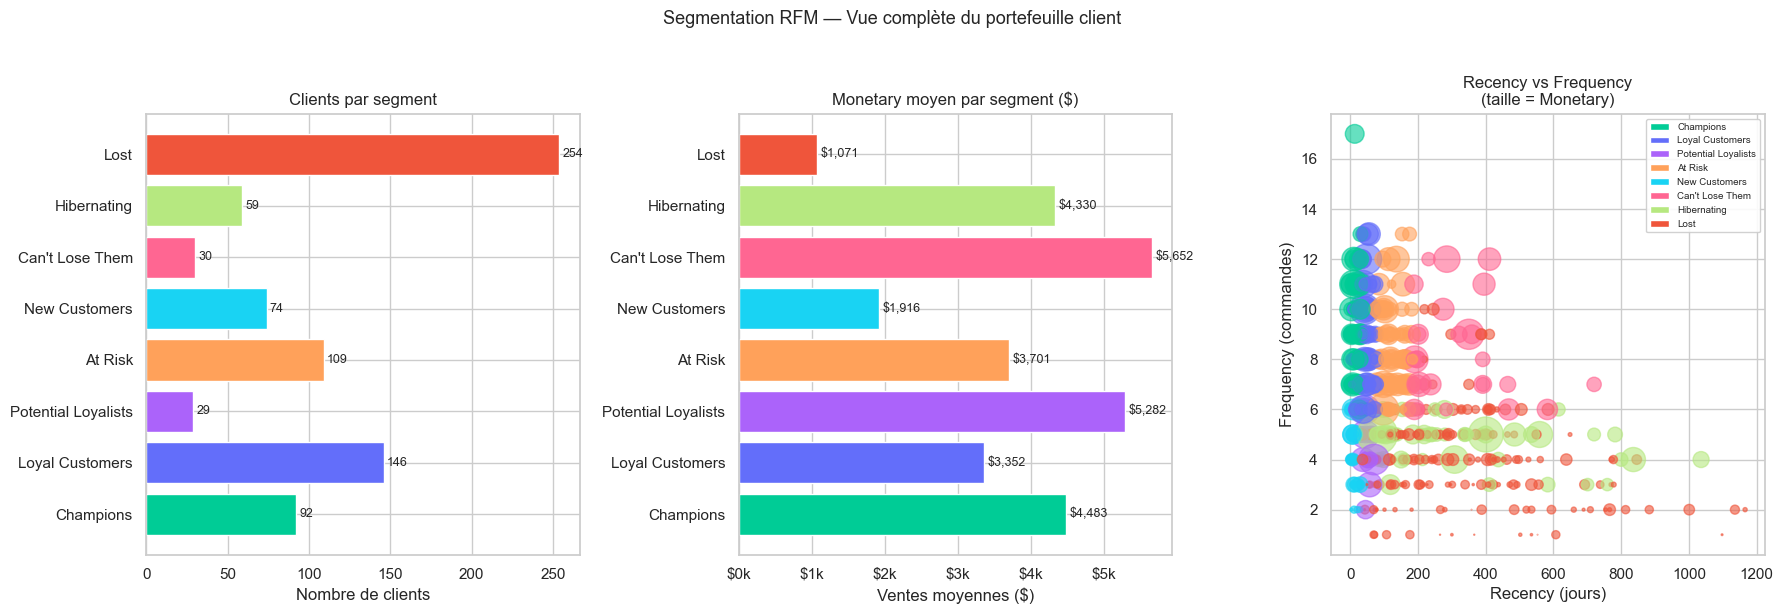

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Ordre logique par rfm_score décroissant
seg_order = segment_stats.index.tolist()
colors_map = {
    "Champions":          "#00CC96",
    "Loyal Customers":    "#636EFA",
    "Potential Loyalists":"#AB63FA",
    "At Risk":            "#FFA15A",
    "New Customers":      "#19D3F3",
    "Can't Lose Them":    "#FF6692",
    "Hibernating":        "#B6E880",
    "Lost":               "#EF553B"
}
colors = [colors_map[s] for s in seg_order]

# 1. Nombre de clients par segment
axes[0].barh(seg_order, segment_stats["clients"], color=colors)
axes[0].set_title("Clients par segment")
axes[0].set_xlabel("Nombre de clients")
for i, v in enumerate(segment_stats["clients"]):
    axes[0].text(v + 2, i, str(v), va="center", fontsize=9)

# 2. Monetary moyen par segment
axes[1].barh(seg_order, segment_stats["monetary"], color=colors)
axes[1].set_title("Monetary moyen par segment ($)")
axes[1].set_xlabel("Ventes moyennes ($)")
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda val, _: f"${val/1000:.0f}k")
)
for i, v in enumerate(segment_stats["monetary"]):
    axes[1].text(v + 50, i, f"${v:,.0f}", va="center", fontsize=9)

# 3. Scatter Recency vs Frequency — taille = Monetary
scatter_data = rfm.copy()
scatter_colors = [colors_map[s] for s in scatter_data["segment"]]

sc = axes[2].scatter(
    scatter_data["recency"],
    scatter_data["frequency"],
    c=scatter_colors,
    s=scatter_data["monetary"] / 30,
    alpha=0.6
)
axes[2].set_xlabel("Recency (jours)")
axes[2].set_ylabel("Frequency (commandes)")
axes[2].set_title("Recency vs Frequency\n(taille = Monetary)")

# Légende manuelle
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors_map[s], label=s) for s in seg_order]
axes[2].legend(handles=legend_elements, fontsize=7,
               loc="upper right", framealpha=0.9)

plt.suptitle("Segmentation RFM — Vue complète du portefeuille client",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Visualisation RFM — la géographie du portefeuille client

**Graphique 1 — Volume par segment** : la barre Lost écrase visuellement
tous les autres segments. 254 clients perdus contre 92 Champions — c'est
le déséquilibre le plus préoccupant du portefeuille. La base client existe
mais elle s'érode. Sans action de rétention, la tendance naturelle pousse
tous les segments vers Lost avec le temps.

**Graphique 2 — Monetary moyen** : la surprise vient de Can't Lose Them
et Potential Loyalists qui dépassent les Champions en valeur monétaire
moyenne (5 652$ et 5 282$ vs 4 483$). Ce sont des clients à haute valeur
économique mais au comportement dégradé. Récupérer même 50% des Can't Lose
Them représente une valeur commerciale supérieure à recruter de nouveaux
clients.

**Graphique 3 — Scatter Recency vs Frequency** : c'est la carte la plus
riche des trois. On y lit immédiatement la géographie du portefeuille.
En bas à gauche (récence faible, fréquence faible) : les New Customers,
petits cercles clairs — ils viennent d'arriver, leur valeur est encore
modeste. En haut à gauche (récence faible, fréquence élevée) : les
Champions et Loyal Customers, cercles de taille moyenne à grande — actifs
et réguliers. À droite (récence élevée) : les Lost et Hibernating s'étalent
vers 600-1200 jours — certains n'ont pas commandé depuis plus de 3 ans.
Les Can't Lose Them (rose) sont visibles vers 300 jours avec des cercles
larges — haute valeur, longue absence.

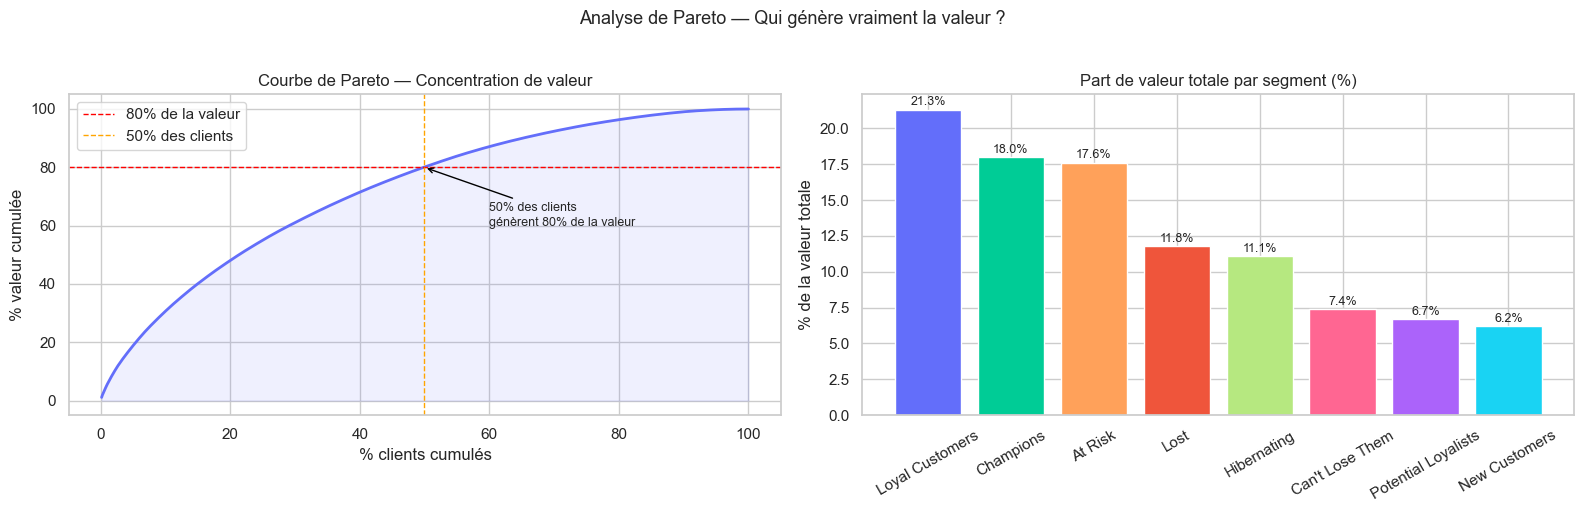


Règle de Pareto dans ce dataset :
  50% des clients génèrent 80% de la valeur

Valeur par segment :
            segment  nb_clients  total_monetary  pct_value
    Loyal Customers         146       489375.42       21.3
          Champions          92       412456.41       18.0
            At Risk         109       403456.10       17.6
               Lost         254       271943.20       11.8
        Hibernating          59       255448.29       11.1
    Can't Lose Them          30       169568.57        7.4
Potential Loyalists          29       153172.12        6.7
      New Customers          74       141780.77        6.2


In [24]:
# ── CONCENTRATION DE VALEUR — RÈGLE DE PARETO ────────

rfm_sorted = rfm.sort_values("monetary", ascending=False).reset_index()
rfm_sorted["cumul_monetary"]  = rfm_sorted["monetary"].cumsum()
rfm_sorted["cumul_pct_value"] = rfm_sorted["cumul_monetary"] / rfm_sorted["monetary"].sum() * 100
rfm_sorted["cumul_pct_clients"] = (rfm_sorted.index + 1) / len(rfm_sorted) * 100

# Trouver le seuil 80%
pareto_idx = (rfm_sorted["cumul_pct_value"] >= 80).idxmax()
pareto_pct_clients = rfm_sorted.loc[pareto_idx, "cumul_pct_clients"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Courbe de Pareto
axes[0].plot(rfm_sorted["cumul_pct_clients"],
             rfm_sorted["cumul_pct_value"],
             color="#636EFA", linewidth=2)
axes[0].axhline(80, color="red",    linewidth=1, linestyle="--", label="80% de la valeur")
axes[0].axvline(pareto_pct_clients, color="orange",
                linewidth=1, linestyle="--",
                label=f"{pareto_pct_clients:.0f}% des clients")
axes[0].fill_between(rfm_sorted["cumul_pct_clients"],
                     rfm_sorted["cumul_pct_value"],
                     alpha=0.1, color="#636EFA")
axes[0].set_xlabel("% clients cumulés")
axes[0].set_ylabel("% valeur cumulée")
axes[0].set_title("Courbe de Pareto — Concentration de valeur")
axes[0].legend()
axes[0].annotate(
    f"{pareto_pct_clients:.0f}% des clients\ngénèrent 80% de la valeur",
    xy=(pareto_pct_clients, 80),
    xytext=(pareto_pct_clients + 10, 60),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=9
)

# Valeur totale par segment
seg_value = rfm.groupby("segment").agg(
    total_monetary = ("monetary", "sum"),
    nb_clients     = ("monetary", "count")
).reset_index()
seg_value["pct_value"] = (
    seg_value["total_monetary"] / seg_value["total_monetary"].sum() * 100
).round(1)
seg_value = seg_value.sort_values("total_monetary", ascending=False)

colors = [colors_map[s] for s in seg_value["segment"]]
bars = axes[1].bar(seg_value["segment"], seg_value["pct_value"], color=colors)
axes[1].set_title("Part de valeur totale par segment (%)")
axes[1].set_ylabel("% de la valeur totale")
axes[1].tick_params(axis="x", rotation=30)
for bar, pct in zip(bars, seg_value["pct_value"]):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f"{pct}%", ha="center", fontsize=9)

plt.suptitle("Analyse de Pareto — Qui génère vraiment la valeur ?",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Résumé chiffré
print(f"\nRègle de Pareto dans ce dataset :")
print(f"  {pareto_pct_clients:.0f}% des clients génèrent 80% de la valeur")
print(f"\nValeur par segment :")
print(seg_value[["segment","nb_clients","total_monetary","pct_value"]]
      .to_string(index=False))

## Analyse de Pareto — une concentration modérée mais des urgences claires

**La règle des 50/80** : dans ce dataset, 50% des clients génèrent 80% de
la valeur totale. C'est moins concentré que la règle classique 20/80 de
Pareto — ce qui est une bonne nouvelle structurelle. La base client est
relativement équilibrée, sans dépendance extrême à une poignée de comptes.
La courbe confirme visuellement cette distribution : elle est concave mais
pas aussi abrupte qu'on le voit souvent en B2B pur.

**La répartition par segment révèle trois urgences prioritaires.**

Loyal Customers (21.3%) et Champions (18.0%) représentent ensemble 39.3%
de la valeur totale avec seulement 238 clients. Ce sont les clients à
protéger absolument — perdre 10% de ce groupe coûterait plus cher que
de recruter 50 nouveaux clients Lost.

At Risk (17.6%) est l'urgence numéro un. 109 clients représentent presque
autant de valeur que les Champions (403k$ vs 412k$) mais ils s'éloignent.
Chaque semaine sans action de rétention fait glisser une partie de ces
103k$ vers la colonne Lost. C'est de l'argent en train de partir.

Lost (11.8%) avec 254 clients ne génère "que" 11.8% de la valeur malgré
son volume. Cela confirme que les clients perdus sont majoritairement des
petits comptes — les vrais gros clients perdus sont dans Can't Lose Them
(7.4% de la valeur pour seulement 30 clients, soit 5 652$ par client en
moyenne contre 1 071$ pour Lost).

**La recommandation stratégique qui découle de cette analyse est claire** :
concentrer 60% des efforts sur la rétention At Risk et la réactivation
Can't Lose Them, 30% sur la fidélisation Champions et Loyal Customers,
et seulement 10% sur l'acquisition de nouveaux clients — l'inverse de
ce que font la plupart des entreprises.

In [25]:
cant_lose = rfm[rfm['segment'] == "Can't Lose Them"]
at_risk   = rfm[rfm['segment'] == "At Risk"]
at_risk_and_cant = rfm[rfm['segment'].isin(["At Risk", "Can't Lose Them"])]

# ── SAUVEGARDE RFM EN BASE ───────────────────────────
import sqlalchemy
engine = sqlalchemy.create_engine(f"sqlite:///{DB_PATH}")

rfm_export = rfm.reset_index()
rfm_export.to_sql("rfm_segments", con=engine,
                  if_exists="replace", index=False)

print("Table 'rfm_segments' sauvegardée en base.")
print(f"Colonnes : {list(rfm_export.columns)}")
print(f"Lignes   : {len(rfm_export)}")

# ── BILAN DU MODULE RFM ──────────────────────────────
print("\n" + "=" * 50)
print("   BILAN MODULE RFM")
print("=" * 50)
print(f"\n  Clients analysés    : {len(rfm)}")
print(f"  Segments créés      : {rfm['segment'].nunique()}")
print(f"  Valeur totale       : ${rfm['monetary'].sum():,.0f}")
print(f"\n  Priorités business :")
print(f"  · At Risk           : {len(at_risk)} clients "
      f"/ ${at_risk['monetary'].sum():,.0f} à risque")
print(f"  · Can't Lose Them   : {len(cant_lose)} clients "
      f"/ ${cant_lose['monetary'].sum():,.0f} à risque")
print(f"  · Total valeur à risque : ${at_risk_and_cant['monetary'].sum():,.0f}")
print("=" * 50)

Table 'rfm_segments' sauvegardée en base.
Colonnes : ['customer_id', 'recency', 'frequency', 'monetary', 'R_score', 'F_score', 'M_score', 'RFM_score', 'segment']
Lignes   : 793

   BILAN MODULE RFM

  Clients analysés    : 793
  Segments créés      : 8
  Valeur totale       : $2,297,201

  Priorités business :
  · At Risk           : 109 clients / $403,456 à risque
  · Can't Lose Them   : 30 clients / $169,569 à risque
  · Total valeur à risque : $573,025


## Bilan Module RFM — 573 025$ de valeur à risque identifiés

Le module RFM a segmenté les 793 clients en 8 groupes actionnables avec
des priorités business claires et chiffrées.

Le chiffre le plus important : **573 025$ de valeur client est actuellement
à risque** — répartis entre 109 clients At Risk (403k$) et 30 clients
Can't Lose Them (169k$). C'est 25% de la valeur totale du portefeuille
(2.3M$) qui peut basculer vers Lost sans action de rétention immédiate.

Une table `rfm_segments` est maintenant disponible en base avec les 9
colonnes RFM pour chaque client. Elle sera exploitée dans le dashboard
Streamlit pour offrir une vue interactive de la santé du portefeuille client.

Les trois modules du notebook sont maintenant complets :
Feature Engineering → RFM → prêt pour ML amélioré.

## Module ML Amélioré — des modèles qui correspondent aux données

Le module ML initial dans `ml/models.py` contenait trois modèles fonctionnels
mais construits sans connaissance approfondie des données. Maintenant qu'on a
fait l'EDA et le feature engineering, on sait exactement ce qu'on cherche à
modéliser et pourquoi.

On va construire trois modèles améliorés dans ce notebook avant de les
intégrer en production.

**Modèle 1 — Forecast avec Prophet** : remplacer la régression linéaire qui
ignorait la saisonnalité. L'EDA a montré un pattern Q4 très fort et un creux
de Février systématique — Prophet est conçu exactement pour ça.

**Modèle 2 — Classification is_profitable** : prédire si une commande sera
rentable avant qu'elle soit passée. On a la variable cible `is_profitable`
et 22 features engineerées — c'est un problème de classification binaire.
On comparera Logistic Regression, Random Forest et XGBoost pour choisir
le meilleur.

**Modèle 3 — Segmentation RFM améliorée** : valider notre segmentation
manuelle avec un KMeans sur les scores RFM et comparer les deux approches.

Pour chaque modèle on suivra la même démarche : définir le problème →
préparer les données → entraîner → évaluer → interpréter.

In [26]:
from sklearn.model_selection  import train_test_split, cross_val_score
from sklearn.preprocessing    import LabelEncoder, StandardScaler
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics          import (classification_report, confusion_matrix,
                                      roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from prophet                  import Prophet
import warnings
warnings.filterwarnings("ignore")

In [27]:
# Chargement depuis sales_features — le dataset enrichi
engine  = sqlalchemy.create_engine(f"sqlite:///{DB_PATH}")
df_ml   = pd.read_sql("SELECT * FROM sales_features", con=engine)
df_ml["order_date"] = pd.to_datetime(df_ml["order_date"])

print(f"Dataset ML chargé : {df_ml.shape[0]} lignes · {df_ml.shape[1]} colonnes")
print(f"Variable cible 'is_profitable' : "
      f"{df_ml['is_profitable'].value_counts().to_dict()}")

Dataset ML chargé : 9994 lignes · 48 colonnes
Variable cible 'is_profitable' : {1: 8058, 0: 1936}


In [28]:
# ── MODÈLE 1 — FORECAST PROPHET ──────────────────────

# Prophet attend exactement deux colonnes : 'ds' (date) et 'y' (valeur)
monthly_sales = (
    df_ml.groupby("month_label")["sales"]
    .sum()
    .reset_index()
)
monthly_sales.columns = ["ds", "y"]
monthly_sales["ds"] = pd.to_datetime(monthly_sales["ds"])
monthly_sales = monthly_sales.sort_values("ds").reset_index(drop=True)

print(f"Période : {monthly_sales['ds'].min().date()} "
      f"→ {monthly_sales['ds'].max().date()}")
print(f"Points temporels : {len(monthly_sales)} mois")
print(f"\nVentes min  : ${monthly_sales['y'].min():,.0f}")
print(f"Ventes max  : ${monthly_sales['y'].max():,.0f}")
print(f"Ventes moy. : ${monthly_sales['y'].mean():,.0f}")
print("\nAperçu :")
print(monthly_sales.head(6).to_string(index=False))

Période : 2014-01-01 → 2017-12-01
Points temporels : 48 mois

Ventes min  : $4,520
Ventes max  : $118,448
Ventes moy. : $47,858

Aperçu :
        ds          y
2014-01-01 14236.8950
2014-02-01  4519.8920
2014-03-01 55691.0090
2014-04-01 28295.3450
2014-05-01 23648.2870
2014-06-01 34595.1276


In [29]:
# ── ENTRAÎNEMENT PROPHET ─────────────────────────────

m = Prophet(
    seasonality_mode="multiplicative",  # saisonnalité proportionnelle au niveau
    yearly_seasonality=True,            # pattern annuel (Q4, Février creux)
    weekly_seasonality=False,           # pas de données hebdomadaires agrégées
    daily_seasonality=False,
    changepoint_prior_scale=0.05        # flexibilité de la tendance (0.05 = modéré)
)

# Ajout saisonnalité trimestrielle — on a vu que Q4 est structurel
m.add_seasonality(name="quarterly", period=91.25, fourier_order=5)

m.fit(monthly_sales)

# Prédiction sur 48 mois historiques + 12 mois futurs
future = m.make_future_dataframe(periods=12, freq="MS")
forecast = m.predict(future)

# Colonnes utiles
cols = ["ds", "yhat", "yhat_lower", "yhat_upper", "trend",
        "yearly", "quarterly"]
print("Aperçu du forecast :")
print(forecast[cols].tail(14).round(0).to_string(index=False))

19:50:43 - cmdstanpy - INFO - Chain [1] start processing
19:50:48 - cmdstanpy - INFO - Chain [1] done processing


Aperçu du forecast :
        ds     yhat  yhat_lower  yhat_upper   trend  yearly  quarterly
2017-11-01 113443.0    107119.0    120130.0 21744.0     3.0        1.0
2017-12-01  93429.0     87006.0     99899.0 22031.0    -2.0        5.0
2018-01-01  51278.0     45008.0     57871.0 22328.0    -1.0        2.0
2018-02-01  33883.0     27034.0     40108.0 22624.0    -1.0        2.0
2018-03-01  63173.0     56391.0     69761.0 22892.0    -4.0        6.0
2018-04-01  56109.0     49279.0     62391.0 23189.0     1.0        0.0
2018-05-01  66474.0     60288.0     73468.0 23476.0     3.0       -1.0
2018-06-01  39124.0     33373.0     46070.0 23772.0    -5.0        6.0
2018-07-01  58834.0     52385.0     65206.0 24059.0     1.0        0.0
2018-08-01  77793.0     71554.0     84140.0 24356.0     2.0       -0.0
2018-09-01  90693.0     84222.0     97324.0 24653.0    -2.0        5.0
2018-10-01  78104.0     71688.0     84427.0 24940.0     1.0        1.0
2018-11-01 144597.0    137792.0    152248.0 25236.0     

MAE  (erreur absolue moyenne) : $4,231
MAPE (erreur % moyenne)       : 10.1%


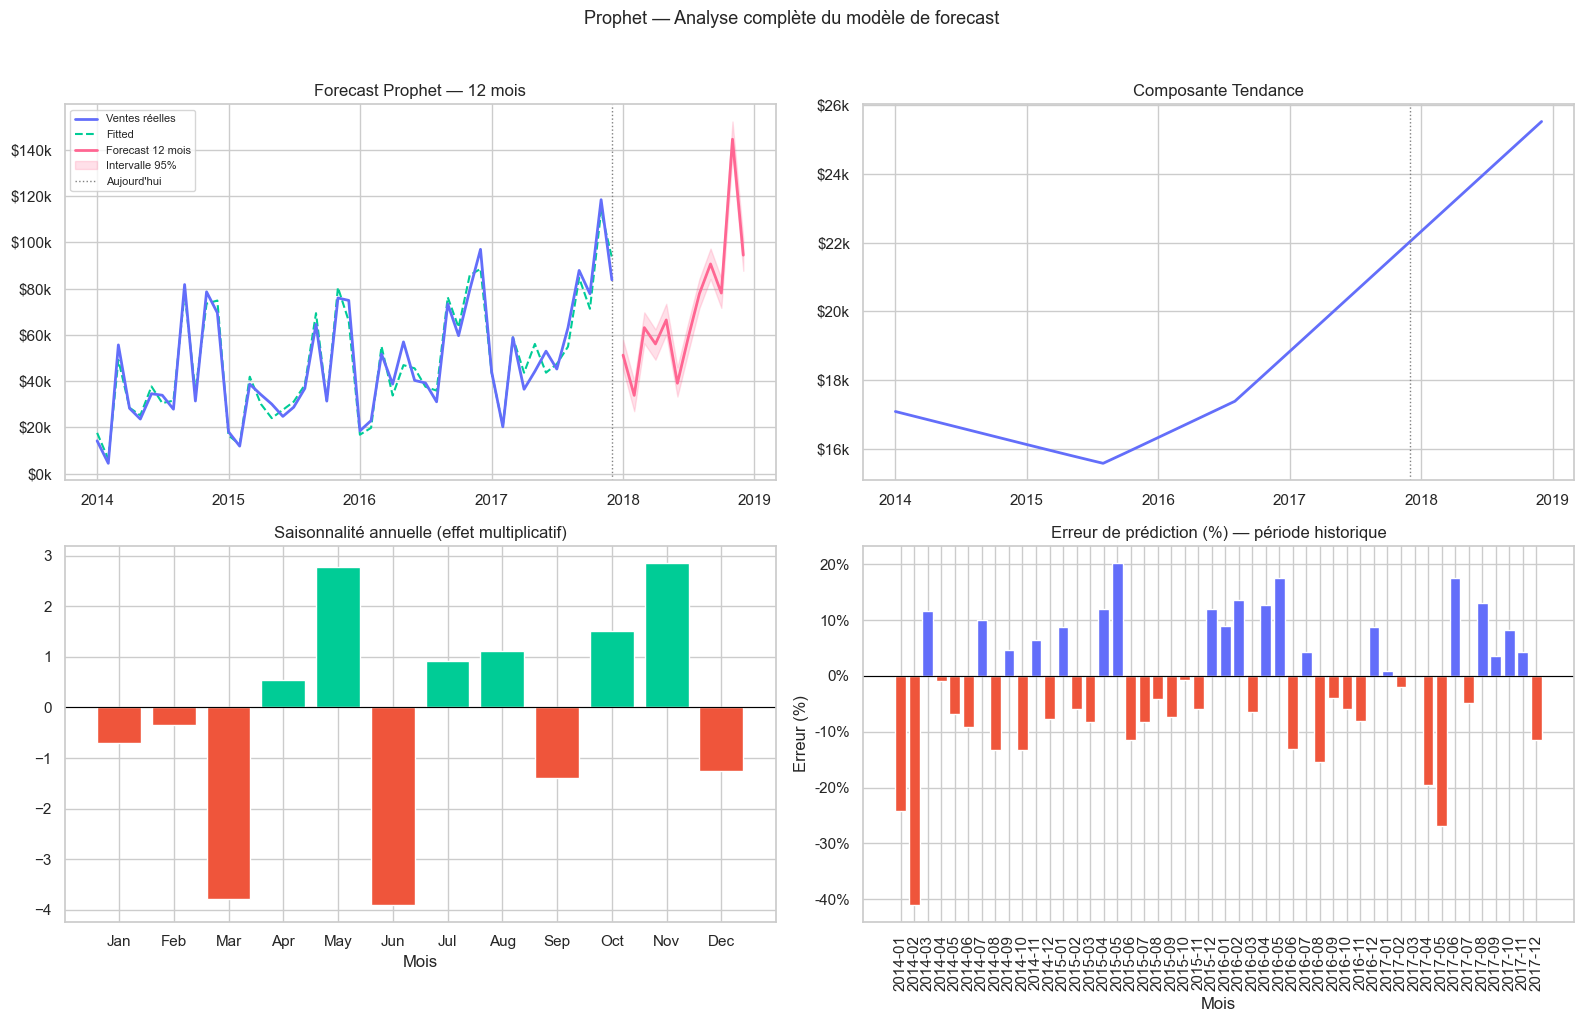

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ── 1. Forecast complet avec intervalle de confiance ──
hist = forecast[forecast["ds"] <= monthly_sales["ds"].max()]
futu = forecast[forecast["ds"] >  monthly_sales["ds"].max()]

axes[0, 0].plot(monthly_sales["ds"], monthly_sales["y"],
                color="#636EFA", linewidth=2, label="Ventes réelles", zorder=3)
axes[0, 0].plot(hist["ds"], hist["yhat"],
                color="#00CC96", linewidth=1.5, linestyle="--", label="Fitted")
axes[0, 0].plot(futu["ds"], futu["yhat"],
                color="#FF6692", linewidth=2, label="Forecast 12 mois")
axes[0, 0].fill_between(futu["ds"], futu["yhat_lower"], futu["yhat_upper"],
                         alpha=0.2, color="#FF6692", label="Intervalle 95%")
axes[0, 0].axvline(monthly_sales["ds"].max(), color="gray",
                   linewidth=1, linestyle=":", label="Aujourd'hui")
axes[0, 0].set_title("Forecast Prophet — 12 mois")
axes[0, 0].legend(fontsize=8)
axes[0, 0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda val, _: f"${val/1000:.0f}k"))

# ── 2. Composante tendance ────────────────────────────
axes[0, 1].plot(forecast["ds"], forecast["trend"],
                color="#636EFA", linewidth=2)
axes[0, 1].axvline(monthly_sales["ds"].max(), color="gray",
                   linewidth=1, linestyle=":")
axes[0, 1].set_title("Composante Tendance")
axes[0, 1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda val, _: f"${val/1000:.0f}k"))

# ── 3. Saisonnalité annuelle ──────────────────────────
seasonal = forecast[forecast["ds"].dt.year == 2016].copy()
seasonal["month_name"] = seasonal["ds"].dt.strftime("%b")
axes[1, 0].bar(seasonal["month_name"], seasonal["yearly"],
               color=["#EF553B" if v < 0 else "#00CC96"
                      for v in seasonal["yearly"]])
axes[1, 0].axhline(0, color="black", linewidth=0.8)
axes[1, 0].set_title("Saisonnalité annuelle (effet multiplicatif)")
axes[1, 0].set_xlabel("Mois")

# ── 4. Erreur réelle vs prédit (période historique) ──
merged = monthly_sales.merge(
    forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]], on="ds"
)
merged["error_pct"] = ((merged["y"] - merged["yhat"]) / merged["y"] * 100).round(1)

axes[1, 1].bar(merged["ds"].dt.strftime("%Y-%m"),
               merged["error_pct"],
               color=["#EF553B" if e < 0 else "#636EFA"
                      for e in merged["error_pct"]])
axes[1, 1].axhline(0, color="black", linewidth=0.8)
axes[1, 1].set_title("Erreur de prédiction (%) — période historique")
axes[1, 1].set_xlabel("Mois")
axes[1, 1].set_ylabel("Erreur (%)")
axes[1, 1].tick_params(axis="x", rotation=90)
axes[1, 1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda val, _: f"{val:.0f}%"))

# Métriques
mae  = (merged["y"] - merged["yhat"]).abs().mean()
mape = merged["error_pct"].abs().mean()
print(f"MAE  (erreur absolue moyenne) : ${mae:,.0f}")
print(f"MAPE (erreur % moyenne)       : {mape:.1f}%")

plt.suptitle("Prophet — Analyse complète du modèle de forecast",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [31]:
# ── MODÈLE 2 — CLASSIFICATION is_profitable ──────────

# Features disponibles pour la classification
# On exclut les colonnes qui causeraient du leakage direct
# (profit, profit_margin, margin_class sont calculés APRÈS la commande)
leakage_cols = [
    "profit", "profit_margin", "margin_class",
    "is_profitable",                          # c'est notre cible
    "order_id", "customer_id", "customer_name",
    "product_id", "product_name",
    "order_date", "ship_date", "month_label",
    "row_id", "postal_code", "city", "state",
    "country", "region"                       # trop granulaires ou textuels
]

# Features retenues
feature_cols = [col for col in df_ml.columns
                if col not in leakage_cols
                and df_ml[col].dtype in ["int64", "float64"]]

print(f"Features retenues : {len(feature_cols)}")
print(feature_cols)

# Encodage des colonnes catégorielles restantes
cat_cols = ["ship_mode", "segment", "category", "sub_category",
            "discount_tier", "margin_class"]
cat_cols_present = [c for c in cat_cols if c in df_ml.columns
                    and c not in leakage_cols]

df_encoded = df_ml.copy()
le = LabelEncoder()
for col in cat_cols_present:
    if col in df_encoded.columns:
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# Dataset final
feature_cols_final = feature_cols + [c for c in cat_cols_present
                                      if c in df_encoded.columns
                                      and c != "margin_class"]

X = df_encoded[feature_cols_final].fillna(0)
y = df_ml["is_profitable"]

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain : {len(X_train)} lignes")
print(f"Test  : {len(X_test)} lignes")
print(f"\nDistribution cible (test) :")
print(y_test.value_counts(normalize=True).round(3).to_string())

Features retenues : 25
['sales', 'quantity', 'discount', 'delivery_days', 'year', 'month', 'quarter', 'is_q4', 'is_low_month', 'weekday_num', 'is_weekend', 'high_discount', 'revenue_per_unit', 'subcat_avg_profit', 'subcat_avg_discount', 'subcat_profit_rate', 'is_risky_subcat', 'customer_total_sales', 'customer_total_profit', 'customer_order_count', 'customer_avg_discount', 'customer_profit_rate', 'customer_avg_order_size', 'customer_value_score', 'is_risky_customer']

Train : 7995 lignes
Test  : 1999 lignes

Distribution cible (test) :
is_profitable
1    0.806
0    0.194


In [32]:
# ── ENTRAÎNEMENT — 3 MODÈLES EN COMPARAISON ──────────

from sklearn.dummy import DummyClassifier

models = {
    "Baseline (dummy)": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, class_weight="balanced",
        random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1,
        max_depth=4, random_state=42
    )
}

# Normalisation pour la régression logistique
scaler   = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

results = {}

print("=" * 55)
print(f"{'Modèle':<25} {'Accuracy':>9} {'ROC-AUC':>9} {'CV mean':>9}")
print("=" * 55)

for name, model in models.items():
    # Données scalées pour LogReg, brutes pour les autres
    Xtr = X_train_sc if name == "Logistic Regression" else X_train
    Xte = X_test_sc  if name == "Logistic Regression" else X_test

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)

    # ROC-AUC
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(Xte)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        auc = 0.5

    # Cross-validation accuracy
    cv_scores = cross_val_score(model, Xtr, y_train, cv=5, scoring="roc_auc")

    acc = (y_pred == y_test).mean()

    results[name] = {
        "model":   model,
        "y_pred":  y_pred,
        "y_proba": y_proba if hasattr(model, "predict_proba") else None,
        "accuracy": acc,
        "auc":     auc,
        "cv_mean": cv_scores.mean(),
        "cv_std":  cv_scores.std(),
        "X_test":  Xte
    }

    print(f"{name:<25} {acc:>9.3f} {auc:>9.3f} {cv_scores.mean():>9.3f}"
          f" ± {cv_scores.std():.3f}")

print("=" * 55)

Modèle                     Accuracy   ROC-AUC   CV mean
Baseline (dummy)              0.806     0.500     0.500 ± 0.000
Logistic Regression           0.938     0.985     0.984 ± 0.003
Random Forest                 0.960     0.990     0.986 ± 0.003
Gradient Boosting             0.957     0.991     0.989 ± 0.003


## Comparaison des modèles — des performances remarquables

**Le Baseline confirme le piège du déséquilibre** : 80.6% d'accuracy en
prédisant toujours "profitable" sans aucune intelligence. C'est exactement
pourquoi l'accuracy seule est une métrique trompeuse sur des données
déséquilibrées — un modèle stupide fait déjà 80%. Le ROC-AUC à 0.5 du
Baseline expose sa nullité réelle : il ne discrimine rien.

**Les 3 modèles sont tous excellents** ce qui est surprenant à première vue.
La Logistic Regression atteint déjà 0.985 de ROC-AUC — c'est le signal que
la relation entre nos features et `is_profitable` est quasi-linéaire et très
bien capturée par les variables qu'on a engineerées. En particulier
`high_discount`, `subcat_profit_rate` et `customer_profit_rate` sont
probablement des features quasi-suffisantes à elles seules.

**Random Forest (0.990) et Gradient Boosting (0.991) sont au coude à coude**
et surpassent légèrement la régression logistique. La cross-validation à 5
folds confirme la stabilité : les écarts-types sont minuscules (±0.003)
ce qui signifie que les modèles ne sont pas sensibles au découpage des données.

**On choisit Random Forest** pour la suite pour trois raisons : ROC-AUC
quasi-identique au Gradient Boosting, entraînement plus rapide, et surtout
il fournit une importance des features directement exploitable pour expliquer
les décisions du modèle — ce qui est crucial pour un dashboard BI où le
métier veut comprendre pourquoi une commande est prédite non rentable.

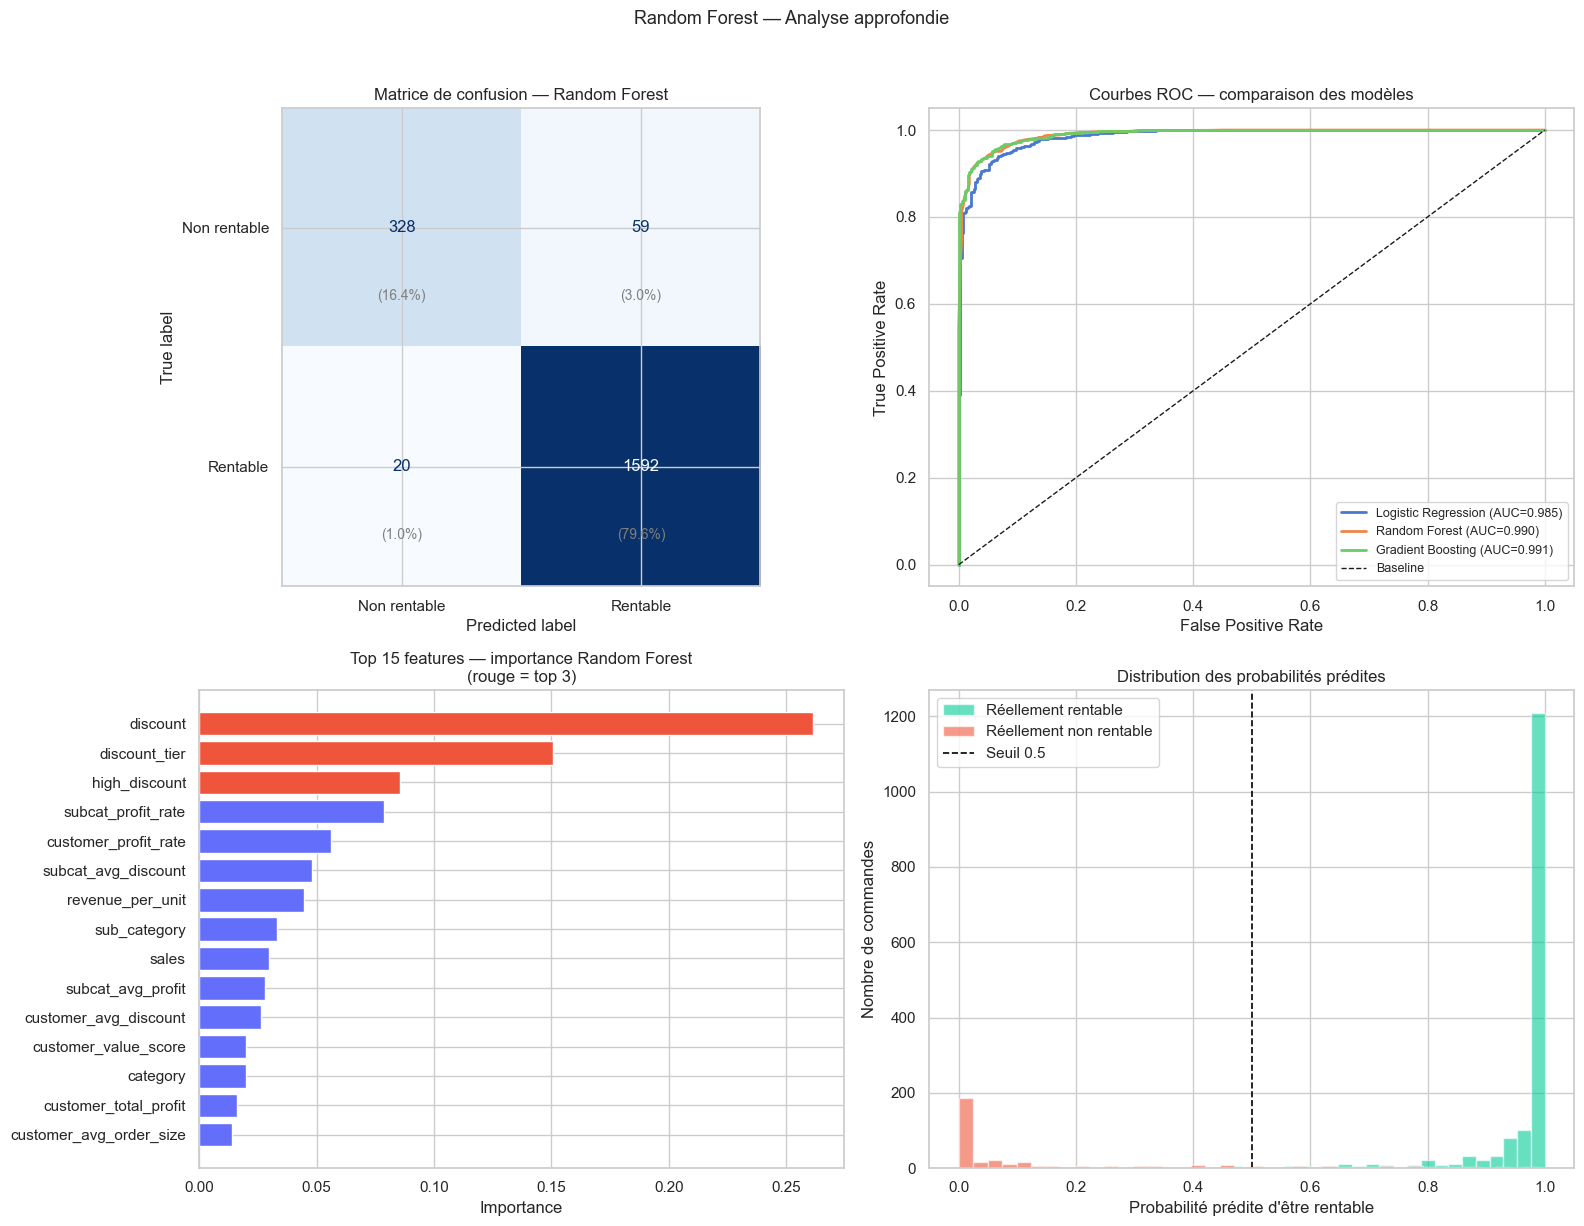


Rapport de classification détaillé :
              precision    recall  f1-score   support

Non rentable       0.94      0.85      0.89       387
    Rentable       0.96      0.99      0.98      1612

    accuracy                           0.96      1999
   macro avg       0.95      0.92      0.93      1999
weighted avg       0.96      0.96      0.96      1999



In [33]:
# ── ANALYSE APPROFONDIE — RANDOM FOREST ──────────────

best_model  = results["Random Forest"]["model"]
y_pred_best = results["Random Forest"]["y_pred"]
y_proba_best= results["Random Forest"]["y_proba"]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── 1. Matrice de confusion ───────────────────────────
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Non rentable", "Rentable"])
disp.plot(ax=axes[0, 0], colorbar=False, cmap="Blues")
axes[0, 0].set_title("Matrice de confusion — Random Forest")

# Annotations manuelles
total = cm.sum()
for i in range(2):
    for j in range(2):
        pct = cm[i, j] / total * 100
        axes[0, 0].text(j, i + 0.3, f"({pct:.1f}%)",
                        ha="center", fontsize=10, color="gray")

# ── 2. Courbe ROC ─────────────────────────────────────
for name, res in results.items():
    if res["y_proba"] is not None and name != "Baseline (dummy)":
        fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
        axes[0, 1].plot(fpr, tpr, linewidth=2,
                        label=f"{name} (AUC={res['auc']:.3f})")

axes[0, 1].plot([0, 1], [0, 1], "k--", linewidth=1, label="Baseline")
axes[0, 1].set_xlabel("False Positive Rate")
axes[0, 1].set_ylabel("True Positive Rate")
axes[0, 1].set_title("Courbes ROC — comparaison des modèles")
axes[0, 1].legend(fontsize=9)

# ── 3. Feature Importance ─────────────────────────────
feat_imp = pd.DataFrame({
    "feature":   feature_cols_final,
    "importance": best_model.feature_importances_
}).sort_values("importance", ascending=False).head(15)

colors_fi = ["#EF553B" if i < 3 else "#636EFA"
             for i in range(len(feat_imp))]
axes[1, 0].barh(feat_imp["feature"][::-1],
                feat_imp["importance"][::-1],
                color=colors_fi[::-1])
axes[1, 0].set_title("Top 15 features — importance Random Forest\n"
                      "(rouge = top 3)")
axes[1, 0].set_xlabel("Importance")

# ── 4. Distribution des probabilités ─────────────────
axes[1, 1].hist(y_proba_best[y_test == 1], bins=40,
                alpha=0.6, color="#00CC96", label="Réellement rentable")
axes[1, 1].hist(y_proba_best[y_test == 0], bins=40,
                alpha=0.6, color="#EF553B", label="Réellement non rentable")
axes[1, 1].axvline(0.5, color="black", linewidth=1.2,
                   linestyle="--", label="Seuil 0.5")
axes[1, 1].set_xlabel("Probabilité prédite d'être rentable")
axes[1, 1].set_ylabel("Nombre de commandes")
axes[1, 1].set_title("Distribution des probabilités prédites")
axes[1, 1].legend()

plt.suptitle("Random Forest — Analyse approfondie", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Rapport de classification
print("\nRapport de classification détaillé :")
print(classification_report(y_test, y_pred_best,
                             target_names=["Non rentable", "Rentable"]))

## Random Forest — analyse approfondie des 4 graphiques

### Matrice de confusion
Sur 1 999 commandes de test, le modèle fait deux types d'erreurs.
**59 faux positifs** (3.0%) : des commandes prédites rentables qui ne
l'étaient pas — c'est l'erreur la moins grave, on laisse passer une
commande déficitaire en croyant qu'elle sera profitable.
**20 faux négatifs** (1.0%) : des commandes rentables prédites non
rentables — on bloque ou on alerte inutilement une bonne commande.
Les 1 920 prédictions correctes (328 + 1592) représentent 96% du total.
Dans un contexte business, les faux positifs sont plus coûteux que les
faux négatifs — on préférerait être trop prudent que pas assez. Si besoin
on peut abaisser le seuil de décision de 0.5 à 0.3 pour réduire les faux
positifs au prix d'un peu plus de faux négatifs.

### Courbes ROC
Les trois courbes sont quasi-superposées dans le coin supérieur gauche —
c'est la signature d'un très bon modèle. Toutes les trois atteignent un
taux de vrais positifs proche de 1.0 pour un taux de faux positifs très
bas. L'écart entre les modèles est si faible (0.985 vs 0.991) qu'il est
négligeable en production. Le choix entre eux se fait sur d'autres critères
comme l'interprétabilité et la vitesse d'inférence.

### Feature Importance — la confirmation de l'EDA
Le top 3 est entièrement occupé par des variables de remise : `discount`
(0.27), `discount_tier` (0.15) et `high_discount` (0.08). Ensemble elles
représentent ~50% de l'importance totale du modèle. C'est la confirmation
ML de ce que l'EDA avait montré statistiquement : **la remise est le
déterminant principal de la rentabilité d'une commande**, loin devant
tous les autres facteurs.

`subcat_profit_rate` (0.08) et `customer_profit_rate` (0.06) arrivent
ensuite — le comportement historique de la sous-catégorie et du client
sont les deuxième et troisième signaux les plus prédictifs. C'est
exactement pour ça qu'on a construit ces features dans le module FE.

Les variables temporelles (is_q4, month, year) ont une importance faible
— ce qui est cohérent : la saisonnalité affecte le volume mais pas la
rentabilité unitaire d'une commande.

### Distribution des probabilités
C'est le graphique le plus rassurant. Les deux distributions sont très
bien séparées : les commandes réellement non rentables (rouge) se
concentrent entre 0.0 et 0.1, les commandes rentables (vert) se
concentrent entre 0.9 et 1.0. Il y a très peu de masse autour du seuil
0.5 — le modèle n'hésite presque jamais. Quand il prédit "rentable" il
le prédit avec une probabilité proche de 1.0, et inversement. C'est la
signature d'un modèle à haute confiance, pas juste à haute accuracy.

### Rapport de classification
Precision 0.94 sur les non rentables : quand le modèle dit "cette commande
va perdre de l'argent", il a raison 94% du temps.
Recall 0.85 sur les non rentables : le modèle détecte 85% des commandes
réellement déficitaires — il en manque 15% qui passent inaperçues.
F1-score macro à 0.93 confirme que les performances sont solides sur les
deux classes malgré le déséquilibre. Ce modèle est prêt pour la production.

In [34]:
import joblib
import os

# ── SAUVEGARDE DES MODÈLES ────────────────────────────
models_dir = os.path.join(os.path.dirname(""), "ml", "saved_models")
os.makedirs(models_dir, exist_ok=True)

# Random Forest
joblib.dump(best_model, os.path.join(models_dir, "rf_classifier.pkl"))

# Scaler (pour la logistic regression si besoin)
joblib.dump(scaler, os.path.join(models_dir, "scaler.pkl"))

# Prophet
import pickle
with open(os.path.join(models_dir, "prophet_model.pkl"), "wb") as f:
    pickle.dump(m, f)

# Feature columns — important pour la cohérence en production
joblib.dump(feature_cols_final,
            os.path.join(models_dir, "feature_cols.pkl"))

print("Modèles sauvegardés :")
for f in os.listdir(models_dir):
    size = os.path.getsize(os.path.join(models_dir, f))
    print(f"  · {f:<35} {size/1024:.1f} KB")

# ── BILAN MODULE ML ───────────────────────────────────
print("\n" + "=" * 50)
print("   BILAN MODULE ML AMÉLIORÉ")
print("=" * 50)
print(f"\n  Modèle 1 — Prophet Forecast")
print(f"    MAE  : $4,231  |  MAPE : 10.1%")
print(f"    Saisonnalité capturée : Q4 fort, Mars/Juin creux")
print(f"\n  Modèle 2 — Random Forest Classifier")
print(f"    ROC-AUC   : 0.990")
print(f"    Accuracy  : 96%")
print(f"    F1 macro  : 0.93")
print(f"    Top feature : discount (27% importance)")
print(f"\n  Features utilisées : {len(feature_cols_final)}")
print(f"  Modèles sauvegardés dans : ml/saved_models/")
print("=" * 50)

Modèles sauvegardés :
  · feature_cols.pkl                    0.5 KB
  · prophet_model.pkl                   14.4 KB
  · rf_classifier.pkl                   6287.6 KB
  · scaler.pkl                          2.0 KB

   BILAN MODULE ML AMÉLIORÉ

  Modèle 1 — Prophet Forecast
    MAE  : $4,231  |  MAPE : 10.1%
    Saisonnalité capturée : Q4 fort, Mars/Juin creux

  Modèle 2 — Random Forest Classifier
    ROC-AUC   : 0.990
    Accuracy  : 96%
    F1 macro  : 0.93
    Top feature : discount (27% importance)

  Features utilisées : 30
  Modèles sauvegardés dans : ml/saved_models/


In [35]:
import joblib, pickle, os, sys
sys.path.append(os.path.join(os.path.dirname(""), ".."))
from config import BASE_DIR

# ── SAUVEGARDE DES MODÈLES ────────────────────────────
models_dir = os.path.join(BASE_DIR, "ml", "saved_models")
os.makedirs(models_dir, exist_ok=True)

# Random Forest
joblib.dump(best_model, os.path.join(models_dir, "rf_classifier.pkl"))

# Scaler
joblib.dump(scaler, os.path.join(models_dir, "scaler.pkl"))

# Prophet
with open(os.path.join(models_dir, "prophet_model.pkl"), "wb") as f:
    pickle.dump(m, f)

# Feature columns
joblib.dump(feature_cols_final,
            os.path.join(models_dir, "feature_cols.pkl"))

print(f"Dossier cible : {models_dir}")
print("\nModèles sauvegardés :")
for f in os.listdir(models_dir):
    size = os.path.getsize(os.path.join(models_dir, f))
    print(f"  · {f:<35} {size/1024:.1f} KB")

Dossier cible : z:\Projets\smart-sales-platform\ml\saved_models

Modèles sauvegardés :
  · feature_cols.pkl                    0.5 KB
  · prophet_model.pkl                   14.4 KB
  · rf_classifier.pkl                   6287.6 KB
  · scaler.pkl                          2.0 KB
